# Day 8: Exercises from the course "Machine Learning using Python (MLUP01)"

**Sessions**: (8) Building Deep Learning Models with TensorFlow/Keras

**Instructor**: Gabriel Rodrigues Palma

**Objective**: This day introduces participants to the core libraries used in machine learning tasks. scikit-learn is used to implement machine learning algorithms, and TensorFlow is used to build deep learning models.

# Importing modules

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import *
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import *
from sklearn.linear_model import *
from sklearn.ensemble import *
from sklearn.svm import *
from sklearn.tree import *
from sklearn.neighbors import *
from sklearn.naive_bayes import *
from sklearn.discriminant_analysis import *
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import validation_curve

import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# SECTION 1: CLASSIFICATION EXAMPLES (10 Examples)

### Classification Example 1: Iris dataset and Logistic regression

In [4]:
print("\n" + "="*50)
print("CLASSIFICATION EXAMPLES")
print("="*50)

# Classification Example 1: Iris Dataset with Logistic Regression
print("\n1. IRIS DATASET - LOGISTIC REGRESSION WITH K-FOLD CV")
print("-" * 60)

# Load dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Create pipeline
iris_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Cross-validation strategy
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation with multiple metrics
iris_scores = cross_validate(iris_pipeline, X_iris, y_iris, cv=kfold,
                            scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

print(f"Accuracy: {iris_scores['test_accuracy'].mean():.4f} ± {iris_scores['test_accuracy'].std():.4f}")
print(f"Precision: {iris_scores['test_precision_macro'].mean():.4f} ± {iris_scores['test_precision_macro'].std():.4f}")
print(f"Recall: {iris_scores['test_recall_macro'].mean():.4f} ± {iris_scores['test_recall_macro'].std():.4f}")
print(f"F1-Score: {iris_scores['test_f1_macro'].mean():.4f} ± {iris_scores['test_f1_macro'].std():.4f}")


CLASSIFICATION EXAMPLES

1. IRIS DATASET - LOGISTIC REGRESSION WITH K-FOLD CV
------------------------------------------------------------
Accuracy: 0.9533 ± 0.0340
Precision: 0.9569 ± 0.0319
Recall: 0.9538 ± 0.0307
F1-Score: 0.9529 ± 0.0324



Confusion Matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  4 46]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.94      0.93        50
   virginica       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



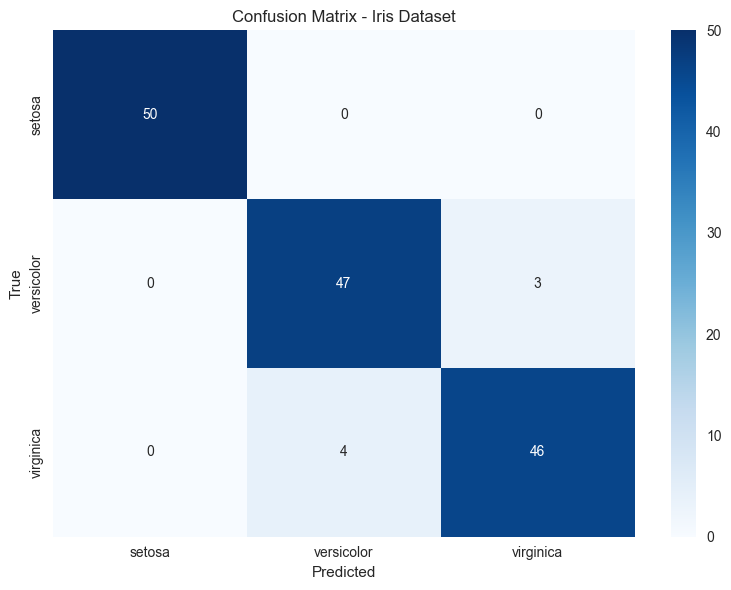

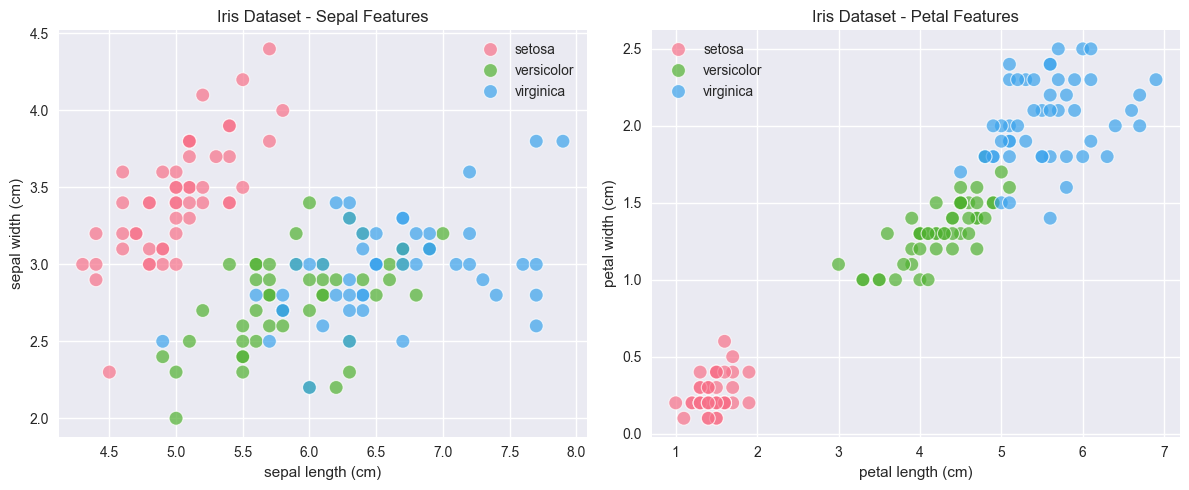

In [50]:
# Train for confusion matrix
iris_pipeline.fit(X_iris, y_iris)
y_pred_iris = cross_val_predict(iris_pipeline, X_iris, y_iris, cv=kfold)
cm_iris = confusion_matrix(y_iris, y_pred_iris)

print("\nConfusion Matrix:")
print(cm_iris)
print("\nClassification Report:")
print(classification_report(y_iris, y_pred_iris, target_names=iris.target_names))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Iris Dataset')
plt.tight_layout()
plt.show()

# Visualize the dataset
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_iris[:, 0], y=X_iris[:, 1], hue=iris.target_names[y_iris], 
                palette='husl', s=100, alpha=0.7)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Iris Dataset - Sepal Features')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_iris[:, 2], y=X_iris[:, 3], hue=iris.target_names[y_iris], 
                palette='husl', s=100, alpha=0.7)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title('Iris Dataset - Petal Features')
plt.tight_layout()
plt.show()

#### Exercises from example 1

In [7]:
print("\nPractice Exercises for Iris Dataset:")
print("1. Modify the pipeline to use different scaling methods (e.g., MinMaxScaler) and compare results.")
print("2. Try different regularization strengths (C parameter) for LogisticRegression and compare performance.")


Practice Exercises for Iris Dataset:
1. Modify the pipeline to use different scaling methods (e.g., MinMaxScaler) and compare results.
2. Try different regularization strengths (C parameter) for LogisticRegression and compare performance.


### Classification Example 2: Breast Cancer Dataset with SVM

In [10]:
print("\n\n2. BREAST CANCER DATASET - SVM WITH STRATIFIED K-FOLD CV")
print("-" * 70)

# Load dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Train-test split for evaluation
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

# Create pipeline
cancer_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('classifier', SVC(probability=True, random_state=42))
])

# Cross-validation strategy
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cancer_scores = cross_validate(cancer_pipeline, X_train_cancer, y_train_cancer, 
                              cv=stratified_kfold, scoring=['accuracy', 'roc_auc', 'f1'])

print(f"Accuracy: {cancer_scores['test_accuracy'].mean():.4f} ± {cancer_scores['test_accuracy'].std():.4f}")
print(f"ROC AUC: {cancer_scores['test_roc_auc'].mean():.4f} ± {cancer_scores['test_roc_auc'].std():.4f}")
print(f"F1-Score: {cancer_scores['test_f1'].mean():.4f} ± {cancer_scores['test_f1'].std():.4f}")



2. BREAST CANCER DATASET - SVM WITH STRATIFIED K-FOLD CV
----------------------------------------------------------------------
Accuracy: 0.9714 ± 0.0112
ROC AUC: 0.9958 ± 0.0042
F1-Score: 0.9772 ± 0.0090



Confusion Matrix:
[[41  1]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



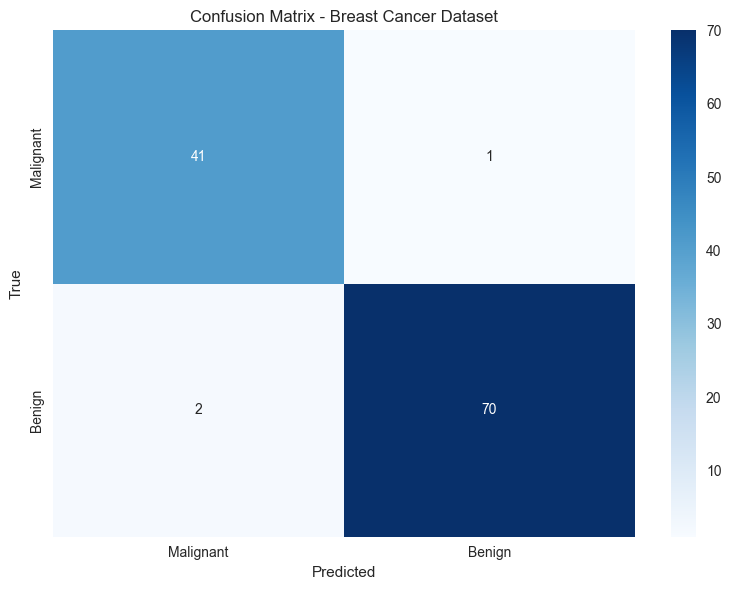

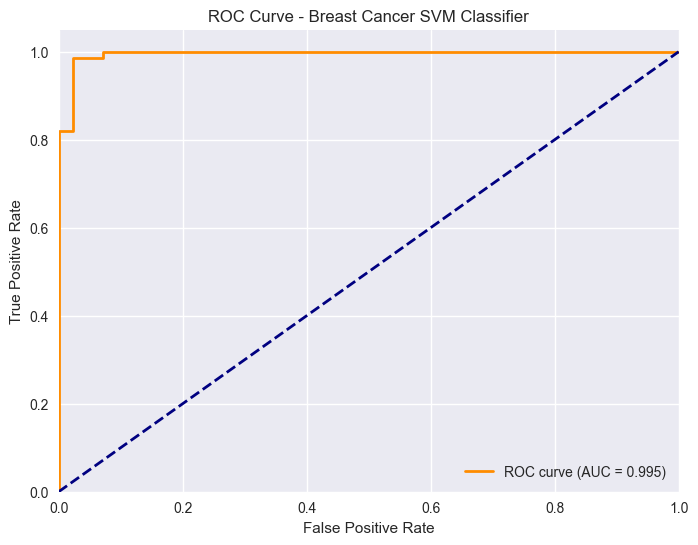

In [11]:
# Train on full training data
cancer_pipeline.fit(X_train_cancer, y_train_cancer)

# Predict on test set
y_pred_cancer = cancer_pipeline.predict(X_test_cancer)
y_pred_proba_cancer = cancer_pipeline.predict_proba(X_test_cancer)[:, 1]

# Calculate metrics
cm_cancer = confusion_matrix(y_test_cancer, y_pred_cancer)
print("\nConfusion Matrix:")
print(cm_cancer)
print("\nClassification Report:")
print(classification_report(y_test_cancer, y_pred_cancer, 
                          target_names=['Malignant', 'Benign']))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cancer, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Breast Cancer Dataset')
plt.tight_layout()
plt.show()

# Plot ROC curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test_cancer, y_pred_proba_cancer)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Breast Cancer SVM Classifier')
plt.legend(loc="lower right")
plt.show()

#### Exercises from example 2

In [20]:
# Practice Exercises for Example 2
print("\nPractice Exercises for Breast Cancer Dataset:")
print("1. Experiment with different kernels for SVM (linear, rbf, poly) and compare performance.")
print("2. Try different numbers of PCA components and observe the impact on model performance.")



Practice Exercises for Breast Cancer Dataset:
1. Experiment with different kernels for SVM (linear, rbf, poly) and compare performance.
2. Try different numbers of PCA components and observe the impact on model performance.


### Classification Example 3: Digits Dataset with Random Forest

In [31]:
print("\n\n3. DIGITS DATASET - RANDOM FOREST WITH TIME SERIES SPLIT")
print("-" * 65)

# Load dataset
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# Create pipeline
digits_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),    
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 5-fold cross validation
cv5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
digits_scores = cross_validate(digits_pipeline, X_digits, y_digits, cv=cv5fold,
                              scoring=['accuracy', 'precision_macro', 'recall_macro'])

print(f"Accuracy: {digits_scores['test_accuracy'].mean():.4f} ± {digits_scores['test_accuracy'].std():.4f}")
print(f"Precision: {digits_scores['test_precision_macro'].mean():.4f} ± {digits_scores['test_precision_macro'].std():.4f}")
print(f"Recall: {digits_scores['test_recall_macro'].mean():.4f} ± {digits_scores['test_recall_macro'].std():.4f}")



3. DIGITS DATASET - RANDOM FOREST WITH TIME SERIES SPLIT
-----------------------------------------------------------------
Accuracy: 0.9772 ± 0.0041
Precision: 0.9779 ± 0.0036
Recall: 0.9771 ± 0.0042


In [32]:
X_digits.shape

(1797, 64)


Confusion Matrix (partial - first 5x5):
[[176   0   0   0   2]
 [  0 182   0   0   0]
 [  1   0 175   0   0]
 [  0   0   0 176   0]
 [  0   0   0   0 178]]


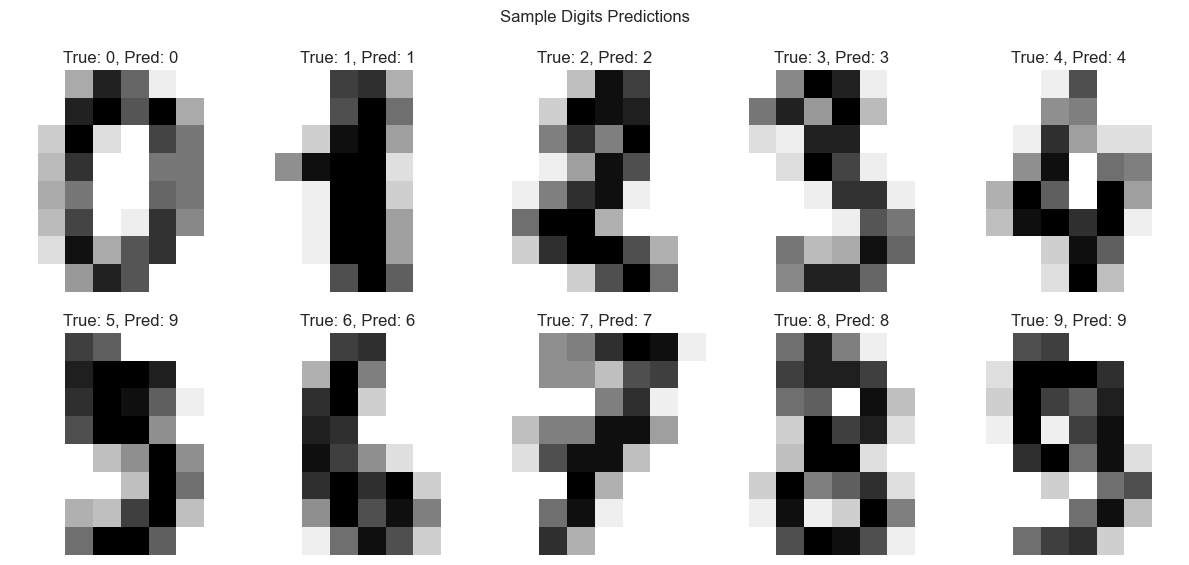

In [33]:
# Get predictions for confusion matrix
y_pred_digits = cross_val_predict(digits_pipeline, X_digits, y_digits, cv=cv5fold)
cm_digits = confusion_matrix(y_digits, y_pred_digits)

print("\nConfusion Matrix (partial - first 5x5):")
print(cm_digits[:5, :5])

# Visualize some digits and their predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(digits.images):
        ax.imshow(digits.images[i], cmap='gray_r')
        ax.set_title(f'True: {y_digits[i]}, Pred: {y_pred_digits[i]}')
        ax.axis('off')
plt.suptitle('Sample Digits Predictions')
plt.tight_layout()
plt.show()

In [39]:
feature_importance_rf

array([0.00000000e+00, 1.87019353e-03, 1.93845356e-02, 9.86654961e-03,
       8.57148820e-03, 2.01888618e-02, 9.73266943e-03, 6.87606249e-04,
       4.90522308e-05, 1.25426095e-02, 2.66481625e-02, 7.04440913e-03,
       1.46991449e-02, 3.14175050e-02, 5.08915551e-03, 8.52732163e-04,
       7.75908560e-05, 7.88635142e-03, 1.91967766e-02, 2.45345454e-02,
       2.88142381e-02, 5.00459194e-02, 8.60997850e-03, 2.58994323e-04,
       1.30477516e-04, 1.46781430e-02, 4.23345674e-02, 2.51969046e-02,
       3.18954600e-02, 2.23019753e-02, 2.69752680e-02, 0.00000000e+00,
       0.00000000e+00, 2.85479652e-02, 2.60777430e-02, 1.54252946e-02,
       4.60670608e-02, 1.82141495e-02, 2.58345056e-02, 0.00000000e+00,
       1.79805622e-05, 1.08041240e-02, 3.90695686e-02, 4.06586911e-02,
       2.11501142e-02, 2.07081069e-02, 2.18070792e-02, 3.66326878e-05,
       0.00000000e+00, 2.98452206e-03, 1.54162180e-02, 2.12366820e-02,
       1.34998917e-02, 2.57156797e-02, 2.84410761e-02, 1.64011118e-03,
      

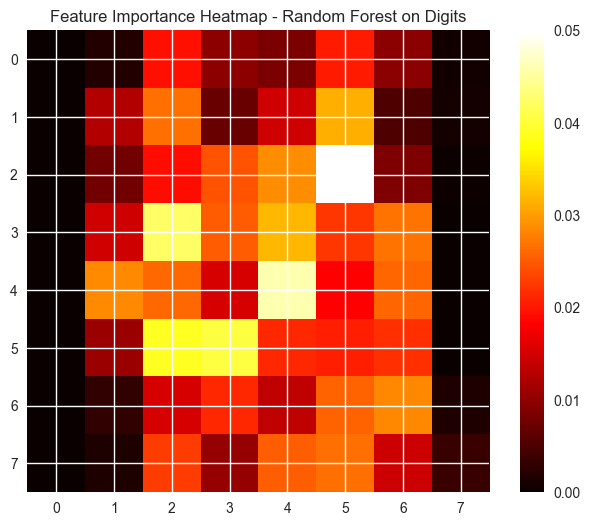

In [38]:
# Feature importance from Random Forest
digits_pipeline.fit(X_digits, y_digits)
feature_importance_rf = digits_pipeline[1].feature_importances_

# Visualize feature importance as a heatmap (8x8 image)
plt.figure(figsize=(8, 6))
plt.imshow(feature_importance_rf.reshape(8, 8), cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Feature Importance Heatmap - Random Forest on Digits')
plt.show()

#### Exercises from example 3

In [40]:
# Practice Exercises for Example 3
print("\nPractice Exercises for Digits Dataset:")
print("1. Try different feature selection methods (mutual_info_classif, chi2) and compare results.")
print("2. Experiment with different tree depths and number of estimators in RandomForest.")


Practice Exercises for Digits Dataset:
1. Try different feature selection methods (mutual_info_classif, chi2) and compare results.
2. Experiment with different tree depths and number of estimators in RandomForest.


## Classification Example 4: Wine Dataset with Naive Bayes

In [46]:
print("\n\n4. WINE DATASET - NAIVE BAYES WITH SHUFFLE SPLIT CV")
print("-" * 60)

# Load dataset
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Create pipeline
wine_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GaussianNB())
])

# Shuffle split cross-validation
shuffle_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
wine_scores = cross_validate(wine_pipeline, X_wine, y_wine, cv=shuffle_split,
                            scoring=['accuracy', 'f1_macro'])

print(f"Accuracy: {wine_scores['test_accuracy'].mean():.4f} ± {wine_scores['test_accuracy'].std():.4f}")
print(f"F1-Score: {wine_scores['test_f1_macro'].mean():.4f} ± {wine_scores['test_f1_macro'].std():.4f}")



4. WINE DATASET - NAIVE BAYES WITH SHUFFLE SPLIT CV
------------------------------------------------------------
Accuracy: 0.9775 ± 0.0276
F1-Score: 0.9788 ± 0.0259



Confusion Matrix:
[[57  2  0]
 [ 1 69  1]
 [ 0  0 48]]


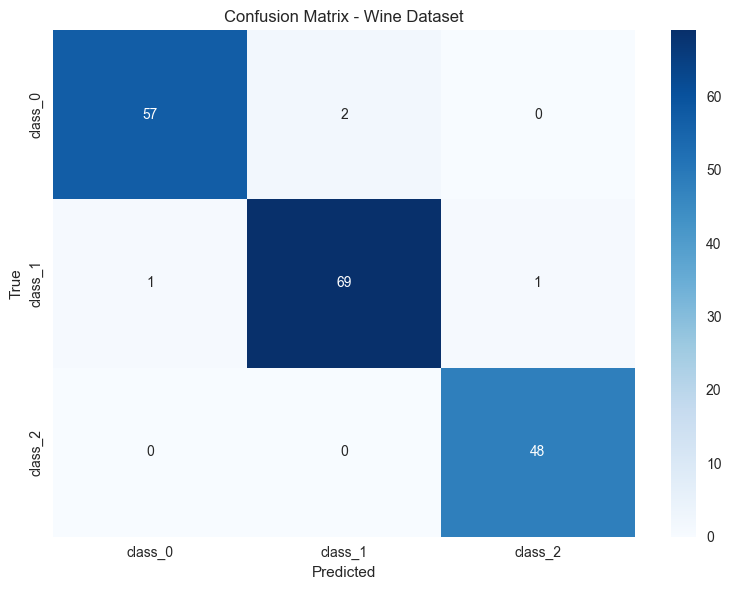

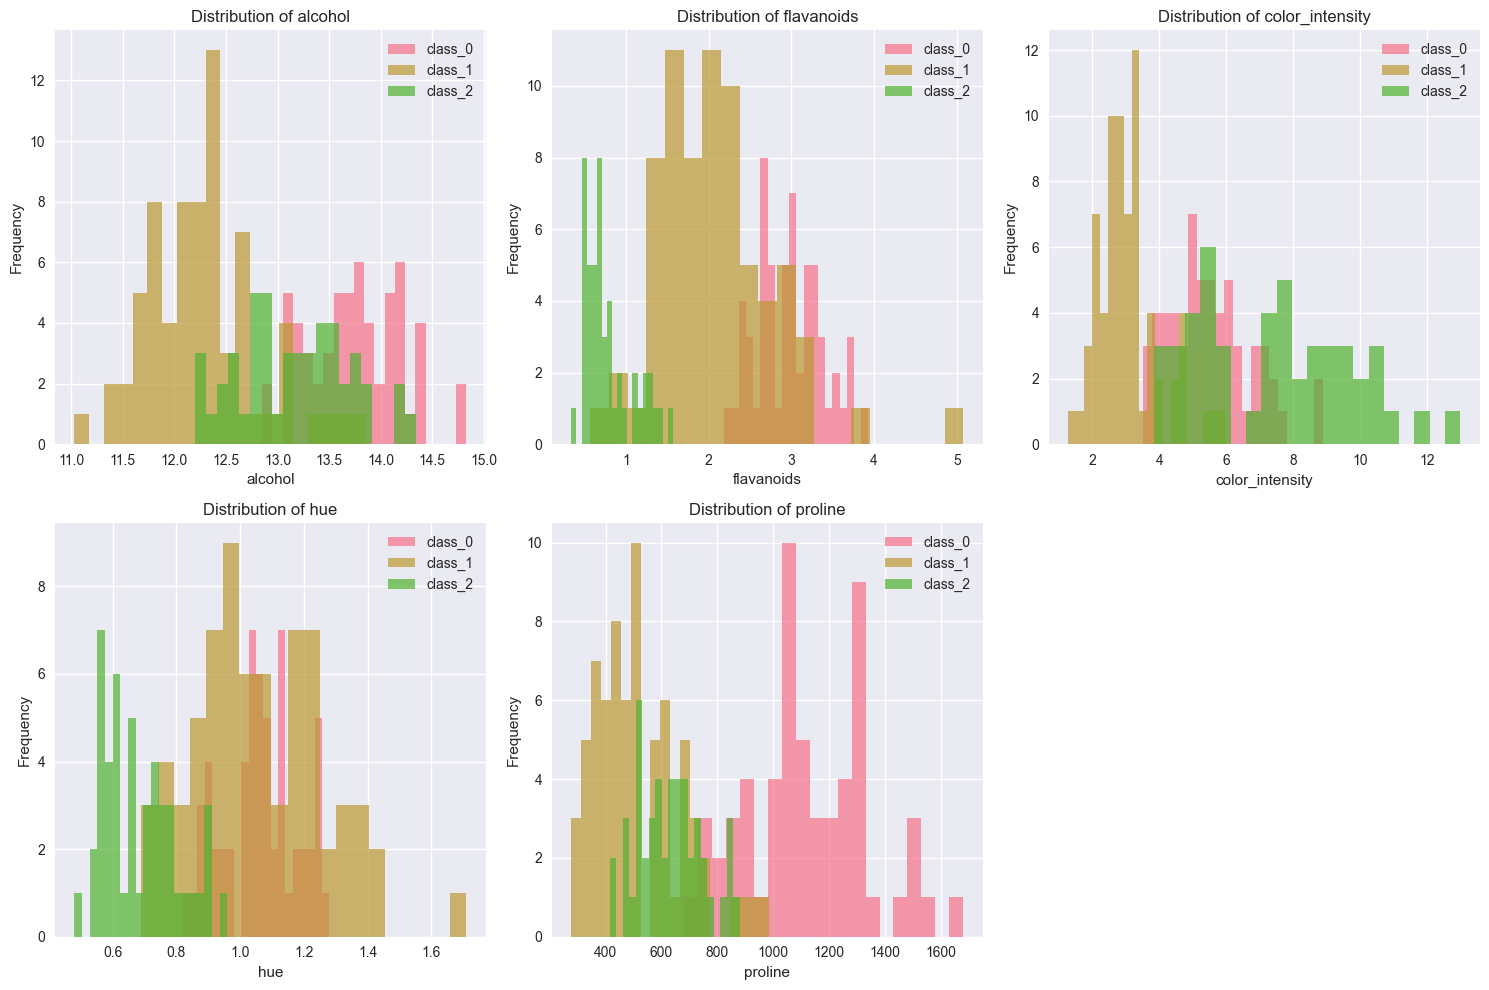

In [48]:
# Get predictions for confusion matrix
y_pred_wine = cross_val_predict(wine_pipeline, X_wine, y_wine, cv=shuffle_split)
cm_wine = confusion_matrix(y_wine, y_pred_wine)

print("\nConfusion Matrix:")
print(cm_wine)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_wine, annot=True, fmt='d', cmap='Blues', 
           xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Wine Dataset')
plt.tight_layout()
plt.show()

# Visualize wine features
plt.figure(figsize=(15, 10))
# Select top 6 features for visualization
top_features = [0, 6, 9, 10, 12]  # alcohol, flavanoids, color_intensity, etc.
feature_names = [wine.feature_names[i] for i in top_features]

for i, feature_idx in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    for class_idx, class_name in enumerate(wine.target_names):
        mask = y_wine == class_idx
        plt.hist(X_wine[mask, feature_idx], alpha=0.7, label=class_name, bins=20)
    plt.xlabel(feature_names[i])
    plt.ylabel('Frequency')
    plt.legend()
    plt.title(f'Distribution of {feature_names[i]}')
plt.tight_layout()
plt.show()

#### Exercises from example 4

In [49]:
# Practice Exercises for Example 4
print("\nPractice Exercises for Wine Dataset:")
print("1. Compare Gaussian NB with MultinomialNB and BernoulliNB performance.")
print("2. Try feature scaling vs. no scaling and observe the impact on Naive Bayes.")



Practice Exercises for Wine Dataset:
1. Compare Gaussian NB with MultinomialNB and BernoulliNB performance.
2. Try feature scaling vs. no scaling and observe the impact on Naive Bayes.


## Classification Example 5: Make_classification synthetic data with KNN

In [55]:
print("\n\n5. SYNTHETIC DATASET - K-NEAREST NEIGHBORS WITH REPEATED STRATIFIED K-FOLD")
print("-" * 80)

# Generate synthetic dataset
X_synth, y_synth = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                                     n_redundant=5, n_clusters_per_class=2, 
                                     random_state=42)

# Create pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Stratified K-Fold cross-validation
rskf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
knn_scores = cross_validate(knn_pipeline, X_synth, y_synth, cv=rskf,
                           scoring=['accuracy', 'precision_macro', 'recall_macro'])

print(f"Accuracy: {knn_scores['test_accuracy'].mean():.4f} ± {knn_scores['test_accuracy'].std():.4f}")
print(f"Precision: {knn_scores['test_precision_macro'].mean():.4f} ± {knn_scores['test_precision_macro'].std():.4f}")
print(f"Recall: {knn_scores['test_recall_macro'].mean():.4f} ± {knn_scores['test_recall_macro'].std():.4f}")



5. SYNTHETIC DATASET - K-NEAREST NEIGHBORS WITH REPEATED STRATIFIED K-FOLD
--------------------------------------------------------------------------------
Accuracy: 0.8580 ± 0.0163
Precision: 0.8582 ± 0.0163
Recall: 0.8580 ± 0.0163



Confusion Matrix:
[[422  75]
 [ 67 436]]


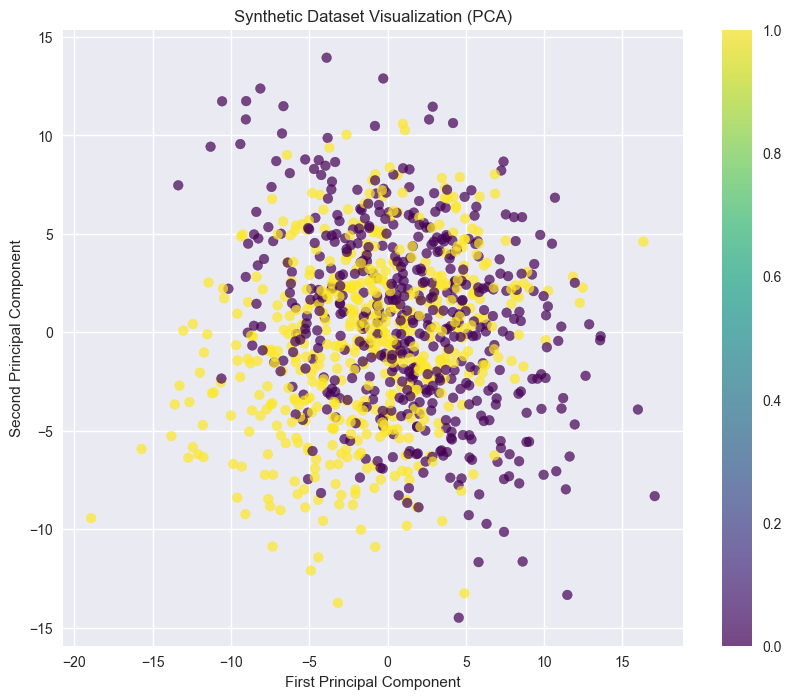

In [57]:
# Get predictions for confusion matrix
y_pred_knn = cross_val_predict(knn_pipeline, X_synth, y_synth, cv=rskf)
cm_knn = confusion_matrix(y_synth, y_pred_knn)

print("\nConfusion Matrix:")
print(cm_knn)

# Visualize the synthetic dataset in 2D using PCA
pca_vis = PCA(n_components=2)
X_synth_2d = pca_vis.fit_transform(X_synth)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_synth_2d[:, 0], X_synth_2d[:, 1], c=y_synth, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Synthetic Dataset Visualization (PCA)')
plt.show()

#### Exercises from example 5

In [58]:
# Practice Exercises for Example 5
print("\nPractice Exercises for Synthetic Dataset:")
print("1. Try different numbers of neighbors (k) and observe the bias-variance tradeoff.")
print("2. Experiment with different distance metrics (euclidean, manhattan, minkowski).")



Practice Exercises for Synthetic Dataset:
1. Try different numbers of neighbors (k) and observe the bias-variance tradeoff.
2. Experiment with different distance metrics (euclidean, manhattan, minkowski).


## Classification Example 6: Fetch_20newsgroups with Decision Tree

In [59]:
print("\n\n6. 20NEWSGROUPS DATASET - DECISION TREE WITH GRID SEARCH CV")
print("-" * 70)

# Load subset of 20newsgroups for computational efficiency
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, 
                               remove=('headers', 'footers', 'quotes'), random_state=42)

# Text preprocessing pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

newsgroups_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english')),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Grid search with cross-validation
param_grid = {
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(newsgroups_pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(newsgroups.data, newsgroups.target)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1-score: {grid_search.best_score_:.4f}")



6. 20NEWSGROUPS DATASET - DECISION TREE WITH GRID SEARCH CV
----------------------------------------------------------------------
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2}
Best F1-score: 0.6090


In [64]:
corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?',
]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())
print(X.toarray())

['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
[[0.         0.46979139 0.58028582 0.38408524 0.         0.
  0.38408524 0.         0.38408524]
 [0.         0.6876236  0.         0.28108867 0.         0.53864762
  0.28108867 0.         0.28108867]
 [0.51184851 0.         0.         0.26710379 0.51184851 0.
  0.26710379 0.51184851 0.26710379]
 [0.         0.46979139 0.58028582 0.38408524 0.         0.
  0.38408524 0.         0.38408524]]


In [67]:
X.toarray().shape

(4, 9)


Confusion Matrix:
[[418  69 129 183]
 [ 54 735 138  46]
 [ 87 101 722  77]
 [217  40 105 266]]


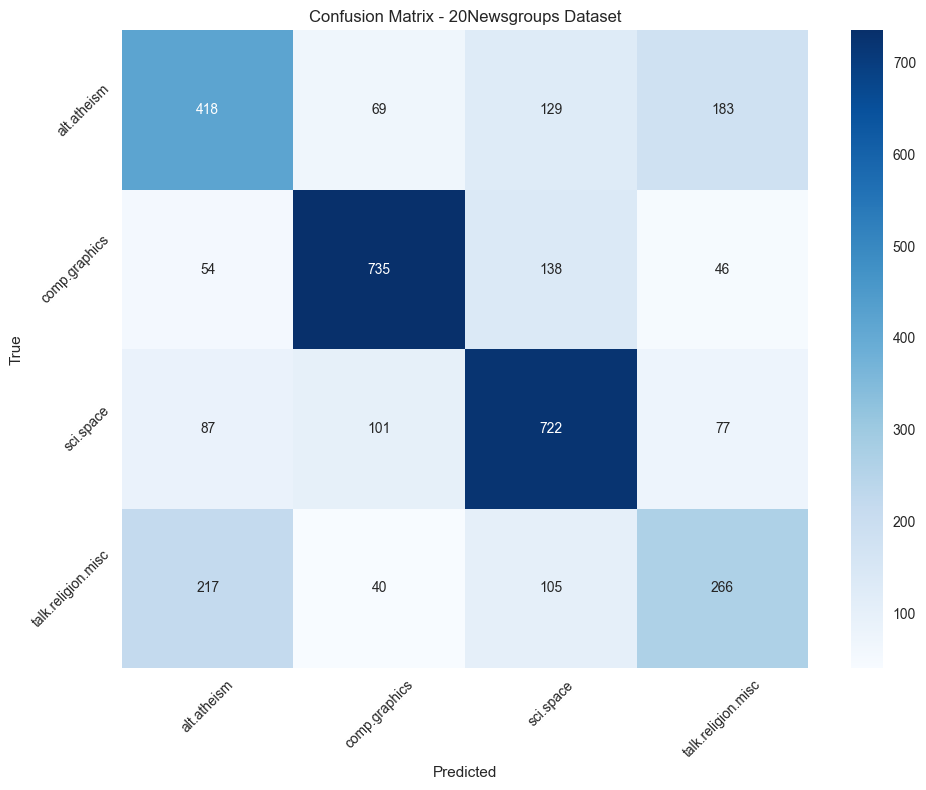

In [62]:
# Get predictions for confusion matrix
y_pred_news = cross_val_predict(grid_search.best_estimator_, newsgroups.data, 
                               newsgroups.target, cv=5)
cm_news = confusion_matrix(newsgroups.target, y_pred_news)

print("\nConfusion Matrix:")
print(cm_news)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_news, annot=True, fmt='d', cmap='Blues', 
           xticklabels=newsgroups.target_names, yticklabels=newsgroups.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - 20Newsgroups Dataset')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

#### Exercises from example 6

In [63]:
# Practice Exercises for Example 6
print("\nPractice Exercises for 20Newsgroups Dataset:")
print("1. Try different text preprocessing techniques (n-grams, different max_features).")
print("2. Compare Decision Tree with other text classifiers like Multinomial Naive Bayes.")


Practice Exercises for 20Newsgroups Dataset:
1. Try different text preprocessing techniques (n-grams, different max_features).
2. Compare Decision Tree with other text classifiers like Multinomial Naive Bayes.


## Classification Example 7: Make_moons with Gradient Boosting

In [5]:
print("\n\n7. MOONS DATASET - GRADIENT BOOSTING WITH LEAVE-ONE-OUT CV")
print("-" * 70)

# Generate moons dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.3, random_state=42)

# Create pipeline
moons_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

# Leave-One-Out cross-validation (for smaller dataset)
loo = LeaveOneOut()

# Since LOO is computationally expensive, let's use a smaller sample
sample_indices = np.random.choice(len(X_moons), size=100, replace=False)
X_moons_sample = X_moons[sample_indices]
y_moons_sample = y_moons[sample_indices]

# Perform cross-validation
moons_scores = cross_validate(moons_pipeline, X_moons_sample, y_moons_sample, 
                             cv=loo, scoring=['accuracy', 'precision', 'recall'])

print(f"Accuracy: {moons_scores['test_accuracy'].mean():.4f} ± {moons_scores['test_accuracy'].std():.4f}")
print(f"ROC AUC: {moons_scores['test_precision'].mean():.4f} ± {moons_scores['test_precision'].std():.4f}")
print(f"ROC AUC: {moons_scores['test_recall'].mean():.4f} ± {moons_scores['test_recall'].std():.4f}")



7. MOONS DATASET - GRADIENT BOOSTING WITH LEAVE-ONE-OUT CV
----------------------------------------------------------------------
Accuracy: 0.9200 ± 0.2713
ROC AUC: 0.4700 ± 0.4991
ROC AUC: 0.4700 ± 0.4991



Confusion Matrix:
[[147   3]
 [  3 147]]


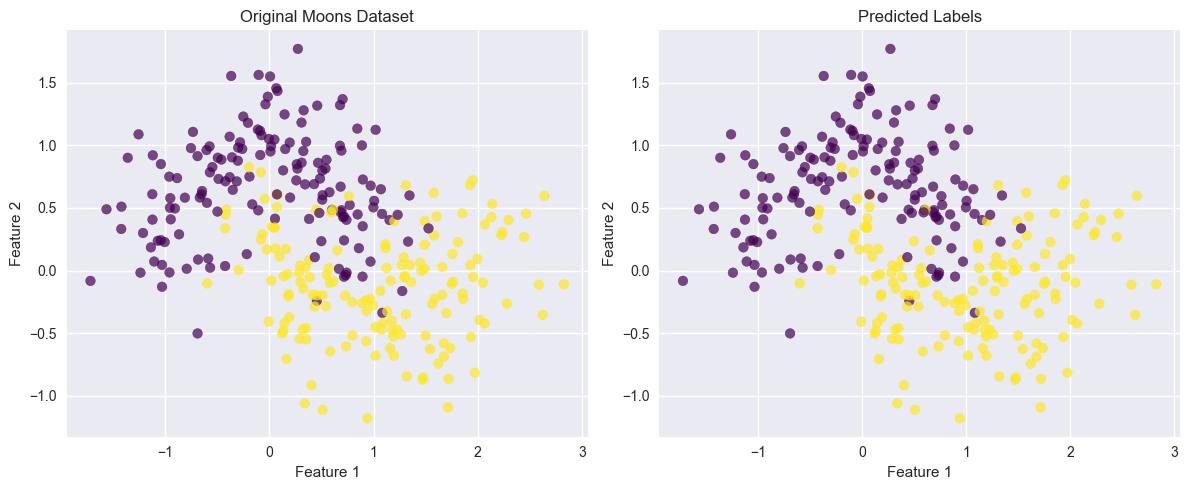

In [6]:
# Fit on full dataset for visualization
moons_pipeline.fit(X_moons, y_moons)
y_pred_moons = moons_pipeline.predict(X_moons)
cm_moons = confusion_matrix(y_moons, y_pred_moons)

print("\nConfusion Matrix:")
print(cm_moons)

# Visualize decision boundary
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.7)
plt.title('Original Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_moons, cmap='viridis', alpha=0.7)
plt.title('Predicted Labels')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

#### Exercises from example 7

In [75]:
# Practice Exercises for Example 7
print("\nPractice Exercises for Moons Dataset:")
print("1. Compare performance with different noise levels in make_moons.")
print("2. Try different boosting algorithms (AdaBoost, XGBoost if available).")


Practice Exercises for Moons Dataset:
1. Compare performance with different noise levels in make_moons.
2. Try different boosting algorithms (AdaBoost, XGBoost if available).


## Classification Example 8: Make_circles with Multi-layer Perceptron

In [7]:
# Generate circles dataset
X_circles, y_circles = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

# Create pipeline
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42))
])

# Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Perform cross-validation
mlp_scores = cross_validate(mlp_pipeline, X_circles, y_circles, cv=skf,
                           scoring=['accuracy', 'precision', 'recall'])

print(f"Accuracy: {mlp_scores['test_accuracy'].mean():.4f} ± {mlp_scores['test_accuracy'].std():.4f}")
print(f"Precision: {mlp_scores['test_precision'].mean():.4f} ± {mlp_scores['test_precision'].std():.4f}")
print(f"Recall: {mlp_scores['test_recall'].mean():.4f} ± {mlp_scores['test_recall'].std():.4f}")

Accuracy: 0.9840 ± 0.0102
Precision: 0.9880 ± 0.0098
Recall: 0.9800 ± 0.0179



Confusion Matrix:
[[247   3]
 [  5 245]]


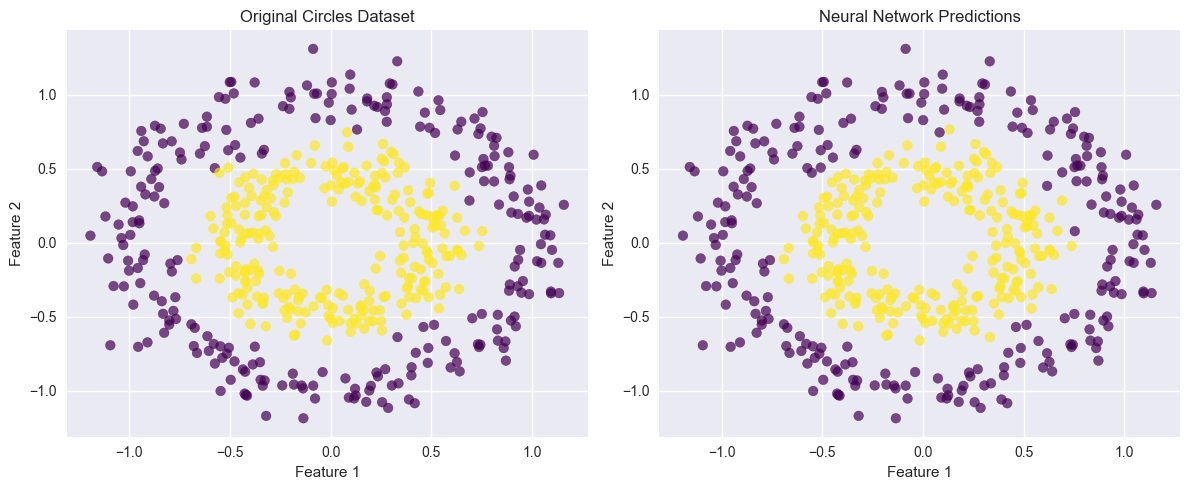

In [8]:
# Get predictions for confusion matrix
y_pred_mlp = cross_val_predict(mlp_pipeline, X_circles, y_circles, cv=skf)
cm_mlp = confusion_matrix(y_circles, y_pred_mlp)

print("\nConfusion Matrix:")
print(cm_mlp)

# Visualize the circles dataset and predictions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', alpha=0.7)
plt.title('Original Circles Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_pred_mlp, cmap='viridis', alpha=0.7)
plt.title('Neural Network Predictions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

#### Exercises from example 8

In [9]:
# Practice Exercises for Example 8
print("\nPractice Exercises for Circles Dataset:")
print("1. Experiment with different neural network architectures (layers, neurons).")
print("2. Try different activation functions and learning rates.")


Practice Exercises for Circles Dataset:
1. Experiment with different neural network architectures (layers, neurons).
2. Try different activation functions and learning rates.


## Classification Example 9: Load_diabetes (converted to classification) with Ensemble Voting

In [10]:
print("\n\n9. DIABETES CLASSIFICATION - ENSEMBLE VOTING WITH CROSS-VAL")
print("-" * 70)

# Load diabetes dataset and convert to classification
diabetes = load_diabetes()
# Convert target to binary classification (above/below median)
diabetes_target_binary = (diabetes.target > np.median(diabetes.target)).astype(int)

# Create ensemble pipeline
from sklearn.ensemble import VotingClassifier

# Individual classifiers
clf1 = Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression(random_state=42))])
clf2 = Pipeline([('scaler', StandardScaler()), ('classifier', SVC(probability=True, random_state=42))])
clf3 = Pipeline([('scaler', StandardScaler()), ('classifier', RandomForestClassifier(random_state=42))])

# Voting classifier
voting_clf = VotingClassifier(estimators=[('lr', clf1), ('svc', clf2), ('rf', clf3)], 
                             voting='soft')

# Cross-validation
cv_scores = cross_validate(voting_clf, diabetes.data, diabetes_target_binary, cv=5,
                          scoring=['accuracy', 'f1', 'roc_auc'])

print(f"Accuracy: {cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}")
print(f"F1-Score: {cv_scores['test_f1'].mean():.4f} ± {cv_scores['test_f1'].std():.4f}")
print(f"ROC AUC: {cv_scores['test_roc_auc'].mean():.4f} ± {cv_scores['test_roc_auc'].std():.4f}")



9. DIABETES CLASSIFICATION - ENSEMBLE VOTING WITH CROSS-VAL
----------------------------------------------------------------------
Accuracy: 0.7171 ± 0.0431
F1-Score: 0.7187 ± 0.0531
ROC AUC: 0.8273 ± 0.0477



Confusion Matrix:
[[155  66]
 [ 59 162]]


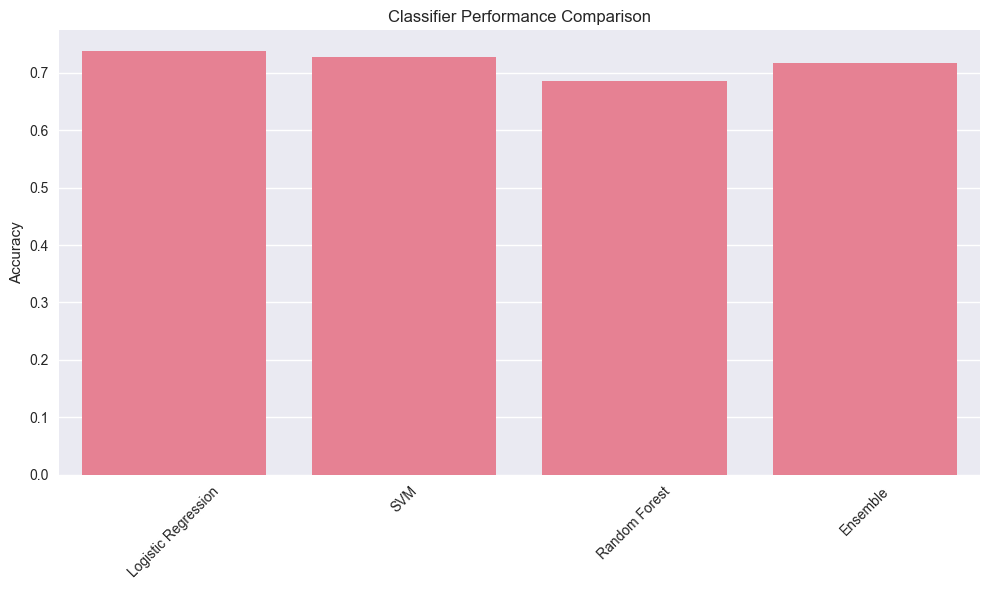

In [11]:
# Get predictions for confusion matrix
y_pred_voting = cross_val_predict(voting_clf, diabetes.data, diabetes_target_binary, cv=5)
cm_voting = confusion_matrix(diabetes_target_binary, y_pred_voting)

print("\nConfusion Matrix:")
print(cm_voting)

# Compare individual classifier performances
individual_scores = {}
for name, clf in [('Logistic Regression', clf1), ('SVM', clf2), ('Random Forest', clf3)]:
    scores = cross_val_score(clf, diabetes.data, diabetes_target_binary, cv=5, scoring='accuracy')
    individual_scores[name] = scores.mean()

# Visualize ensemble vs individual performance
plt.figure(figsize=(10, 6))
names = list(individual_scores.keys()) + ['Ensemble']
scores = list(individual_scores.values()) + [cv_scores['test_accuracy'].mean()]
sns.barplot(x=names, y=scores)
plt.title('Classifier Performance Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Exercises from Example 9

In [12]:
print("\nPractice Exercises for Diabetes Classification:")
print("1. Try hard voting vs soft voting and compare results.")
print("2. Add more classifiers to the ensemble and observe performance changes.")


Practice Exercises for Diabetes Classification:
1. Try hard voting vs soft voting and compare results.
2. Add more classifiers to the ensemble and observe performance changes.


## Classification Example 10: Olivetti Faces with Linear Discriminant Analysis

In [17]:
print("\n\n10. OLIVETTI FACES - LINEAR DISCRIMINANT ANALYSIS WITH GROUP K-FOLD")
print("-" * 75)

# Load Olivetti faces dataset
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)
X_faces, y_faces = olivetti.data, olivetti.target

# Create groups for GroupKFold (simulate different sessions)
groups = np.repeat(np.arange(40), 10)  # 10 images per person

# Create pipeline
lda_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),  # Reduce dimensionality
    ('classifier', LinearDiscriminantAnalysis())
])

# Group K-Fold cross-validation
gkf = GroupKFold(n_splits=5)

# Perform cross-validation
faces_scores = cross_validate(lda_pipeline, X_faces, y_faces, groups=groups, cv=gkf,
                             scoring=['accuracy', 'f1_macro'])

print(f"Accuracy: {faces_scores['test_accuracy'].mean():.4f} ± {faces_scores['test_accuracy'].std():.4f}")
print(f"F1-Score: {faces_scores['test_f1_macro'].mean():.4f} ± {faces_scores['test_f1_macro'].std():.4f}")



10. OLIVETTI FACES - LINEAR DISCRIMINANT ANALYSIS WITH GROUP K-FOLD
---------------------------------------------------------------------------
Accuracy: 0.9875 ± 0.0079
F1-Score: 0.9825 ± 0.0113



Confusion Matrix (subset 200 samples, partial view):
[[2 0 0 0 0 1 0 0 0 0]
 [0 4 0 0 0 1 0 0 0 0]
 [0 0 2 0 0 0 0 0 0 0]
 [0 0 0 2 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0]
 [0 0 0 0 1 3 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 4 0 0]
 [0 0 0 0 0 0 0 0 5 0]
 [0 0 0 0 0 0 0 0 1 3]]


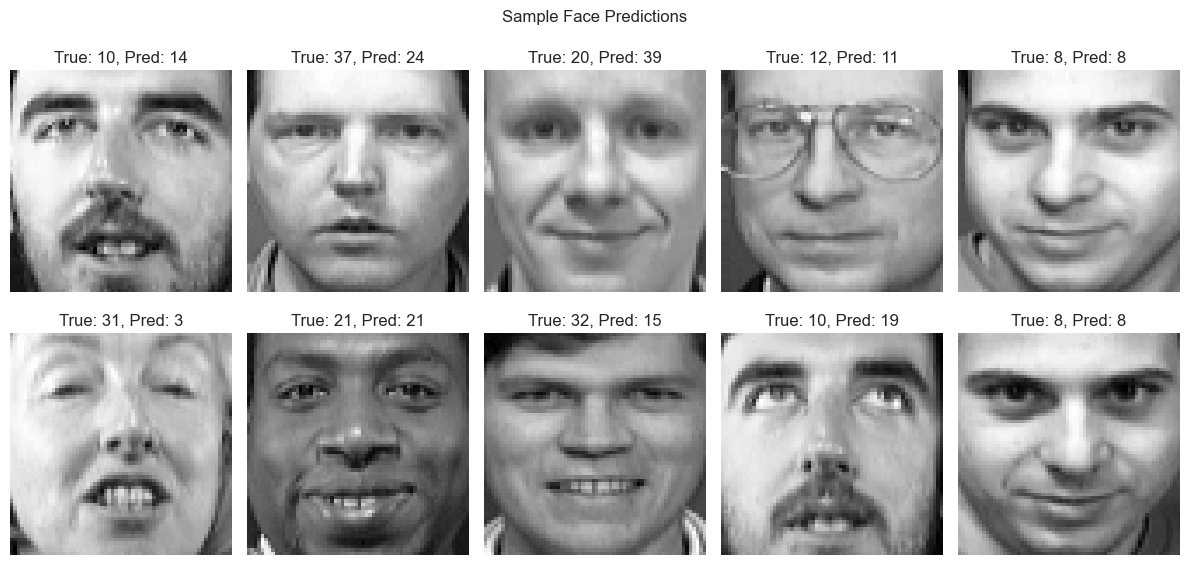

In [18]:
# Get a subset for confusion matrix (too large otherwise)
subset_size = 200
indices = np.random.choice(len(X_faces), subset_size, replace=False)
X_subset = X_faces[indices]
y_subset = y_faces[indices]
groups_subset = groups[indices]

y_pred_faces = cross_val_predict(lda_pipeline, X_subset, y_subset, 
                               groups=groups_subset, cv=GroupKFold(n_splits=3))
cm_faces = confusion_matrix(y_subset, y_pred_faces)

print(f"\nConfusion Matrix (subset {subset_size} samples, partial view):")
print(cm_faces[:10, :10])  # Show only first 10x10

# Visualize some faces and their predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_subset):
        face_image = X_subset[i].reshape(64, 64)
        ax.imshow(face_image, cmap='gray')
        ax.set_title(f'True: {y_subset[i]}, Pred: {y_pred_faces[i]}')
        ax.axis('off')
plt.suptitle('Sample Face Predictions')
plt.tight_layout()
plt.show()


#### Exercises from Example 10

In [19]:
# Practice Exercises for Example 10
print("\nPractice Exercises for Olivetti Faces:")
print("1. Try different dimensionality reduction techniques (ICA, NMF) before LDA.")
print("2. Compare LDA with Quadratic Discriminant Analysis performance.")


Practice Exercises for Olivetti Faces:
1. Try different dimensionality reduction techniques (ICA, NMF) before LDA.
2. Compare LDA with Quadratic Discriminant Analysis performance.


# SECTION 2: REGRESSION EXAMPLES (10 Examples)

In [21]:
# Regression Example 1: Boston Housing with Linear Regression
print("\n\n1. CALIFORNIA HOUSING - LINEAR REGRESSION WITH K-FOLD CV")
print("-" * 70)

# Load dataset
california = fetch_california_housing()
X_calif, y_calif = california.data, california.target

# Create pipeline
calif_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# K-Fold cross-validation
kfold_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation with multiple metrics
calif_scores = cross_validate(calif_pipeline, X_calif, y_calif, cv=kfold_reg,
                             scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'])

print(f"R² Score: {calif_scores['test_r2'].mean():.4f} ± {calif_scores['test_r2'].std():.4f}")
print(f"MSE: {-calif_scores['test_neg_mean_squared_error'].mean():.4f} ± {calif_scores['test_neg_mean_squared_error'].std():.4f}")
print(f"MAE: {-calif_scores['test_neg_mean_absolute_error'].mean():.4f} ± {calif_scores['test_neg_mean_absolute_error'].std():.4f}")



1. CALIFORNIA HOUSING - LINEAR REGRESSION WITH K-FOLD CV
----------------------------------------------------------------------
R² Score: 0.6014 ± 0.0170
MSE: 0.5306 ± 0.0218
MAE: 0.5317 ± 0.0084


RMSE: 0.7284


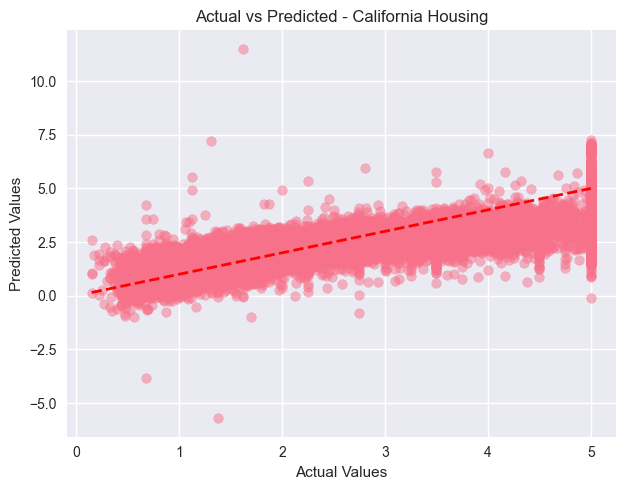

In [23]:
# Get predictions for visualization
y_pred_calif = cross_val_predict(calif_pipeline, X_calif, y_calif, cv=kfold_reg)

# Calculate RMSE
rmse_calif = np.sqrt(mean_squared_error(y_calif, y_pred_calif))
print(f"RMSE: {rmse_calif:.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_calif, y_pred_calif, alpha=0.5)
plt.plot([y_calif.min(), y_calif.max()], [y_calif.min(), y_calif.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted - California Housing')
plt.tight_layout()
plt.show()

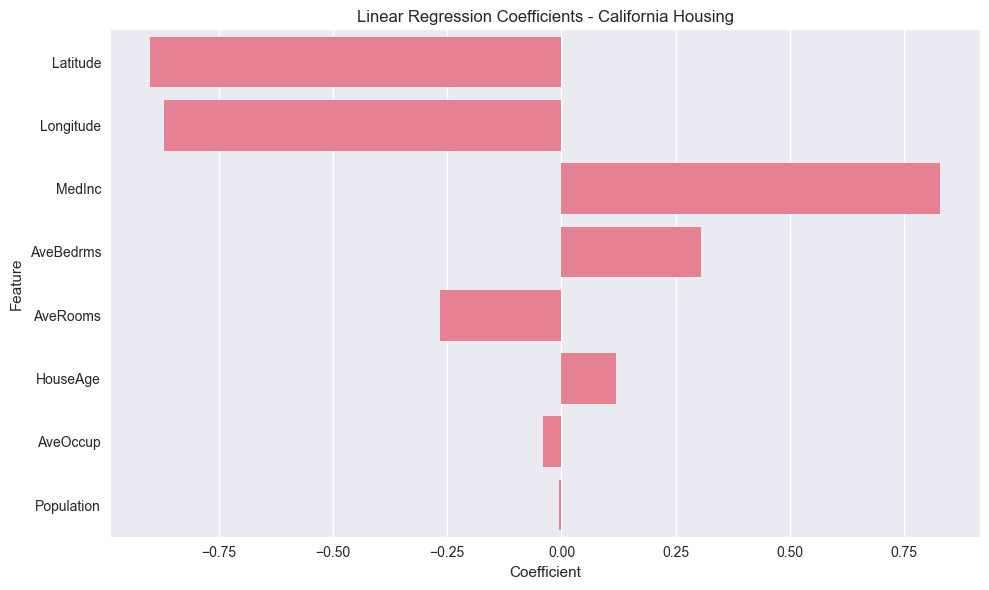

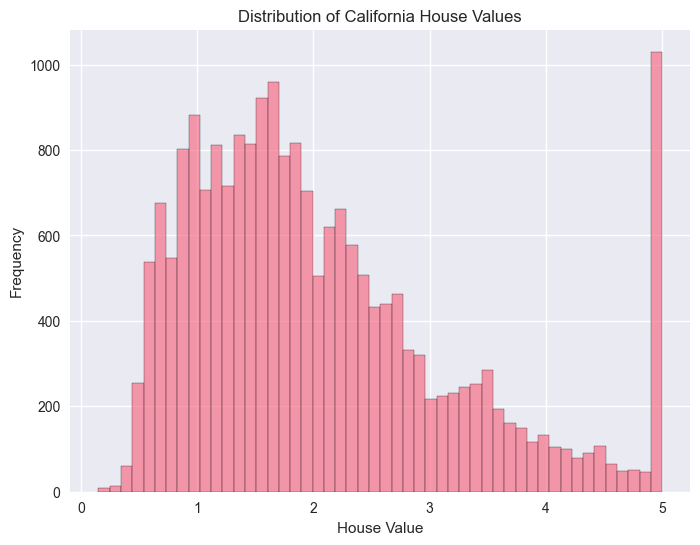

In [24]:
# Feature importance visualization
calif_pipeline.fit(X_calif, y_calif)
coefficients = calif_pipeline[1].coef_

plt.figure(figsize=(10, 6))
feature_names = california.feature_names
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Linear Regression Coefficients - California Housing')
plt.tight_layout()
plt.show()

# Distribution of target variable
plt.figure(figsize=(8, 6))
plt.hist(y_calif, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('House Value')
plt.ylabel('Frequency')
plt.title('Distribution of California House Values')
plt.show()

#### Exercises from Example 1

In [25]:
# Practice Exercises for Example 1
print("\nPractice Exercises for California Housing:")
print("1. Try polynomial features with different degrees and compare performance.")
print("2. Apply Ridge or Lasso regression and compare with basic Linear Regression.")



Practice Exercises for California Housing:
1. Try polynomial features with different degrees and compare performance.
2. Apply Ridge or Lasso regression and compare with basic Linear Regression.


## Regression Example 2: Diabetes Dataset with Ridge Regression

In [26]:
print("\n\n2. DIABETES DATASET - RIDGE REGRESSION WITH STRATIFIED K-FOLD")
print("-" * 70)

# Load dataset
diabetes_reg = load_diabetes()
X_diab, y_diab = diabetes_reg.data, diabetes_reg.target

# Create stratified bins for continuous target
y_diab_binned = pd.cut(y_diab, bins=5, labels=False)

# Create pipeline
diabetes_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

# Stratified K-Fold (using binned target)
skf_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
diabetes_scores = cross_validate(diabetes_pipeline, X_diab, y_diab, 
                               cv=skf_reg.split(X_diab, y_diab_binned),
                               scoring=['neg_mean_squared_error', 'r2'])

print(f"R² Score: {diabetes_scores['test_r2'].mean():.4f} ± {diabetes_scores['test_r2'].std():.4f}")
print(f"MSE: {-diabetes_scores['test_neg_mean_squared_error'].mean():.4f} ± {diabetes_scores['test_neg_mean_squared_error'].std():.4f}")



2. DIABETES DATASET - RIDGE REGRESSION WITH STRATIFIED K-FOLD
----------------------------------------------------------------------
R² Score: 0.4893 ± 0.0691
MSE: 3004.7514 ± 324.0669


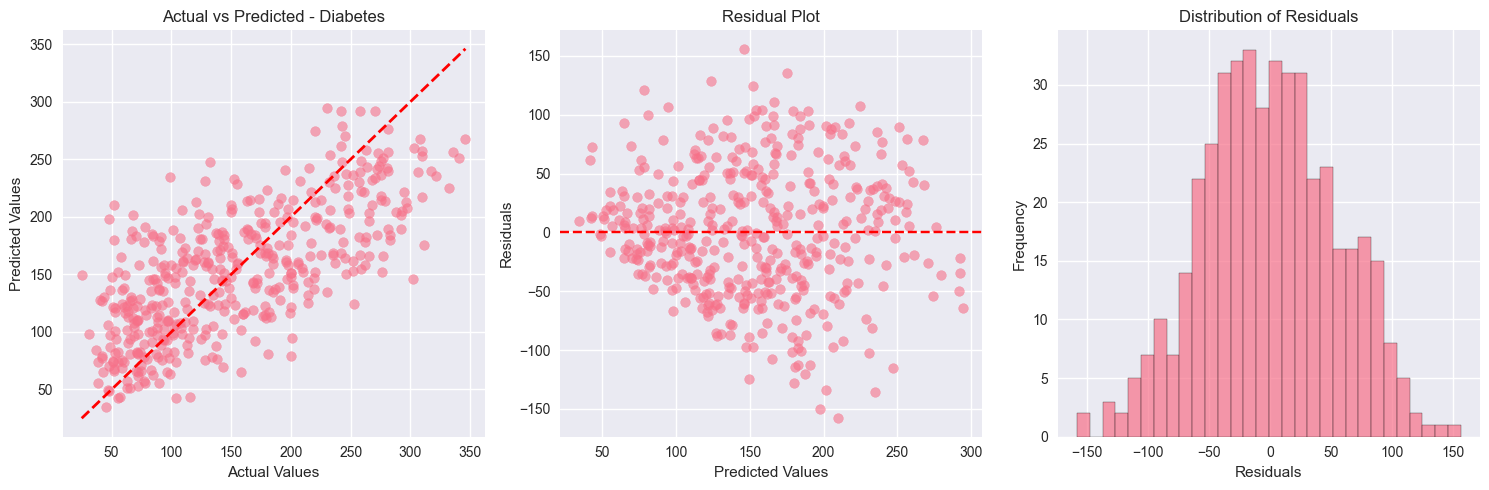

In [27]:
# Get predictions
y_pred_diab = cross_val_predict(diabetes_pipeline, X_diab, y_diab, 
                               cv=skf_reg.split(X_diab, y_diab_binned))

# Visualize results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_diab, y_pred_diab, alpha=0.6)
plt.plot([y_diab.min(), y_diab.max()], [y_diab.min(), y_diab.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted - Diabetes')

plt.subplot(1, 3, 2)
residuals = y_diab - y_pred_diab
plt.scatter(y_pred_diab, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 3, 3)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

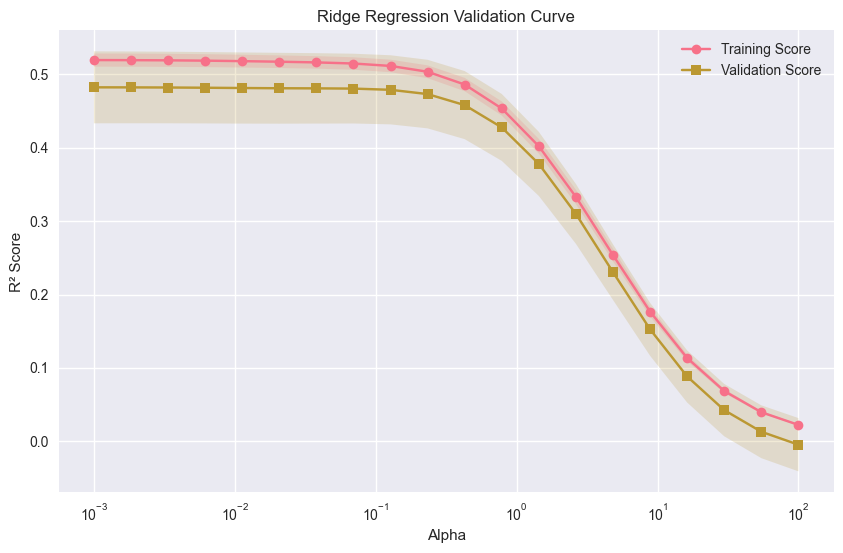

In [29]:
# Cross-validation curve for Ridge alpha
alphas = np.logspace(-3, 2, 20)
train_scores, val_scores = validation_curve(
    Ridge(), X_diab, y_diab, param_name='alpha', param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1)

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, train_scores.mean(axis=1), label='Training Score', marker='o')
plt.fill_between(alphas, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2)
plt.semilogx(alphas, val_scores.mean(axis=1), label='Validation Score', marker='s')
plt.fill_between(alphas, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge Regression Validation Curve')
plt.legend()
plt.grid(True)
plt.show()

#### Exercises from Example 2

In [30]:
# Practice Exercises for Example 2
print("\nPractice Exercises for Diabetes Dataset:")
print("1. Compare Ridge with Lasso and Elastic Net regularization.")
print("2. Use GridSearchCV to find optimal alpha parameter.")


Practice Exercises for Diabetes Dataset:
1. Compare Ridge with Lasso and Elastic Net regularization.
2. Use GridSearchCV to find optimal alpha parameter.


## Regression Example 3: Make_regression with Random Forest

In [80]:
print("\n\n3. SYNTHETIC REGRESSION - RANDOM FOREST WITH TIME SERIES SPLIT")
print("-" * 75)

# Generate synthetic regression dataset
X_synth_reg, y_synth_reg = make_regression(n_samples=1000, n_features=10, 
                                         noise=0.1, random_state=42)

# Create pipeline
rf_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# K-Fold cross-validation
kfold_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
rf_reg_scores = cross_validate(rf_reg_pipeline, X_synth_reg, y_synth_reg, cv=kfold_reg,
                              scoring=['neg_mean_squared_error', 'r2'])

print(f"R² Score: {rf_reg_scores['test_r2'].mean():.4f} ± {rf_reg_scores['test_r2'].std():.4f}")
print(f"MSE: {-rf_reg_scores['test_neg_mean_squared_error'].mean():.4f} ± {rf_reg_scores['test_neg_mean_squared_error'].std():.4f}")



3. SYNTHETIC REGRESSION - RANDOM FOREST WITH TIME SERIES SPLIT
---------------------------------------------------------------------------
R² Score: 0.8437 ± 0.0229
MSE: 2719.9271 ± 424.4564


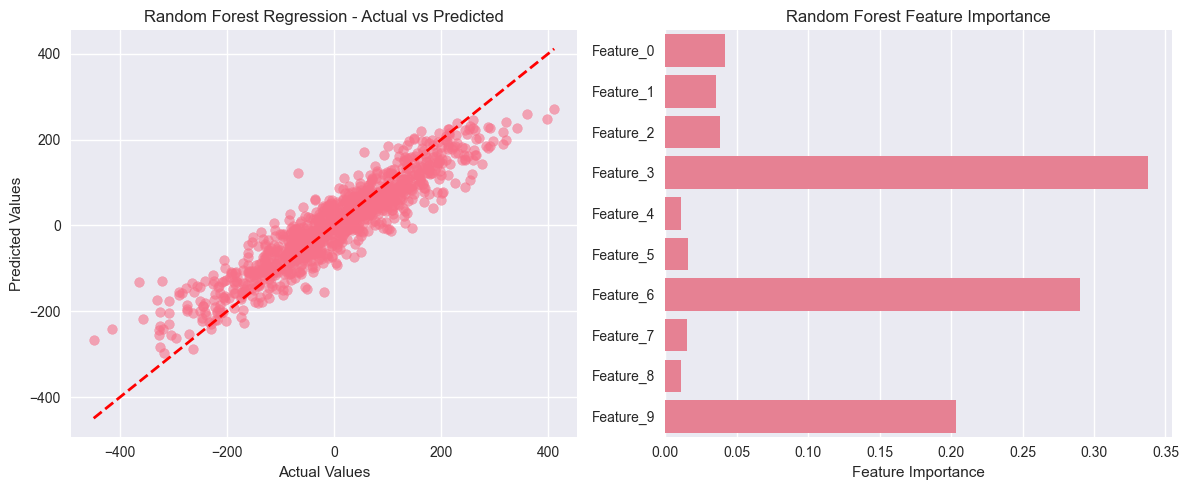

In [82]:
# Get predictions
y_pred_rf_reg = cross_val_predict(rf_reg_pipeline, X_synth_reg, y_synth_reg, cv=kfold_reg)

# Feature importance
rf_reg_pipeline.fit(X_synth_reg, y_synth_reg)
feature_importance = rf_reg_pipeline[1].feature_importances_

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_synth_reg, y_pred_rf_reg, alpha=0.6)
plt.plot([y_synth_reg.min(), y_synth_reg.max()], [y_synth_reg.min(), y_synth_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Regression - Actual vs Predicted')

plt.subplot(1, 2, 2)
feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]
sns.barplot(x=feature_importance, y=feature_names)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

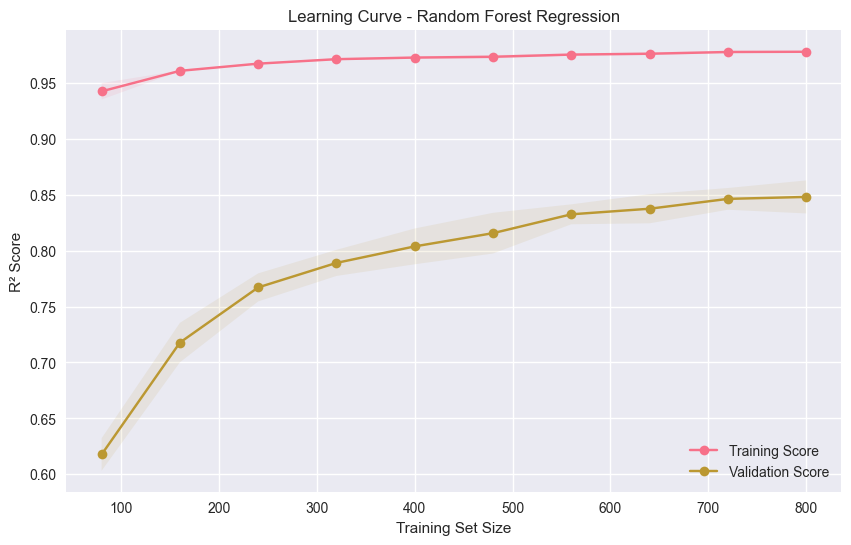

In [83]:
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    rf_reg_pipeline, X_synth_reg, y_synth_reg, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2')

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_lc.mean(axis=1), 'o-', label='Training Score')
plt.fill_between(train_sizes, train_scores_lc.mean(axis=1) - train_scores_lc.std(axis=1),
                 train_scores_lc.mean(axis=1) + train_scores_lc.std(axis=1), alpha=0.1)
plt.plot(train_sizes, val_scores_lc.mean(axis=1), 'o-', label='Validation Score')
plt.fill_between(train_sizes, val_scores_lc.mean(axis=1) - val_scores_lc.std(axis=1),
                 val_scores_lc.mean(axis=1) + val_scores_lc.std(axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve - Random Forest Regression')
plt.legend()
plt.grid(True)
plt.show()

#### Exercises from example 3

In [84]:
# Practice Exercises for Example 3
print("\nPractice Exercises for Synthetic Regression:")
print("1. Experiment with different numbers of estimators and max_depth.")
print("2. Compare Random Forest with Extra Trees Regressor.")



Practice Exercises for Synthetic Regression:
1. Experiment with different numbers of estimators and max_depth.
2. Compare Random Forest with Extra Trees Regressor.


## Regression Example 4: Boston Housing with Gradient Boosting

In [87]:
print("\n\n4. BOSTON HOUSING - GRADIENT BOOSTING WITH SHUFFLE SPLIT")
print("-" * 70)

# Load sklearn's Boston Housing dataset
X_boston, y_boston = fetch_openml(name='boston', version=1, return_X_y=True, as_frame=True)

# Create pipeline
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# K-Fold cross-validation
kfold_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
gb_scores = cross_validate(gb_pipeline, X_boston, y_boston, cv=kfold_reg,
                         scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'])

print(f"R² Score: {gb_scores['test_r2'].mean():.4f} ± {gb_scores['test_r2'].std():.4f}")
print(f"MSE: {-gb_scores['test_neg_mean_squared_error'].mean():.4f} ± {gb_scores['test_neg_mean_squared_error'].std():.4f}")
print(f"MAE: {-gb_scores['test_neg_mean_absolute_error'].mean():.4f} ± {gb_scores['test_neg_mean_absolute_error'].std():.4f}")




4. BOSTON HOUSING - GRADIENT BOOSTING WITH SHUFFLE SPLIT
----------------------------------------------------------------------
R² Score: 0.8949 ± 0.0281
MSE: 8.7420 ± 2.6038
MAE: 2.0947 ± 0.1418


RMSE: 2.9559


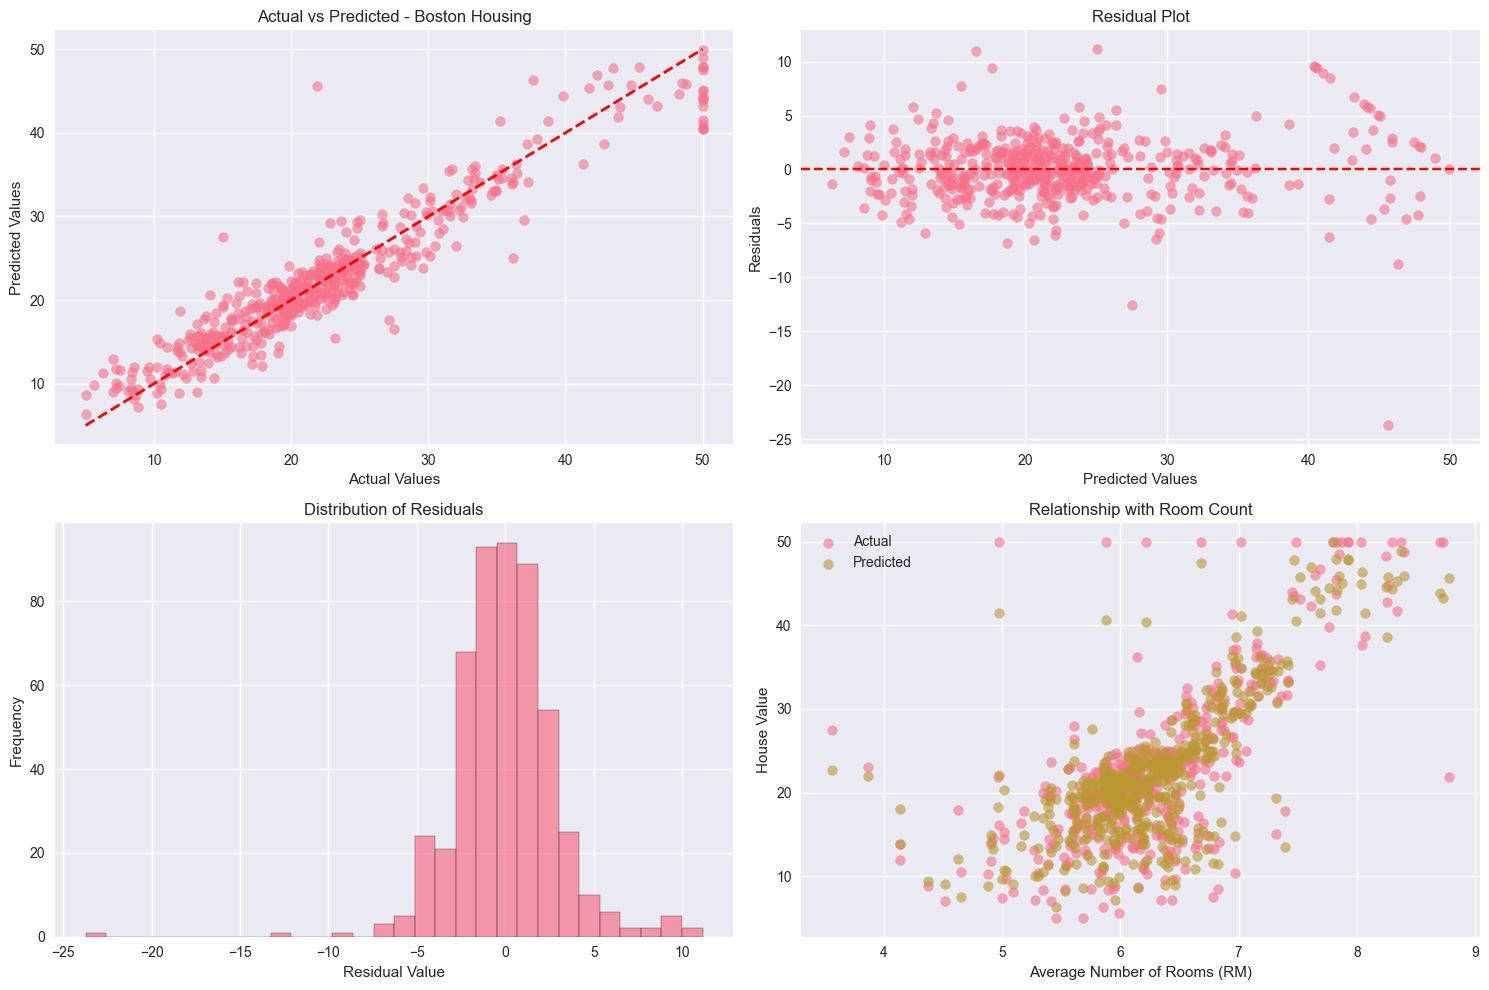

In [89]:
# Get predictions
y_pred_gb = cross_val_predict(gb_pipeline, X_boston, y_boston, cv=kfold_reg)

# Calculate RMSE
rmse_gb = np.sqrt(mean_squared_error(y_boston, y_pred_gb))
print(f"RMSE: {rmse_gb:.4f}")

# Visualizations
plt.figure(figsize=(15, 10))

# Actual vs Predicted
plt.subplot(2, 2, 1)
plt.scatter(y_boston, y_pred_gb, alpha=0.6)
plt.plot([y_boston.min(), y_boston.max()], [y_boston.min(), y_boston.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted - Boston Housing')

# Residuals
residuals_gb = y_boston - y_pred_gb
plt.subplot(2, 2, 2)
plt.scatter(y_pred_gb, residuals_gb, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# Histogram of Residuals
plt.subplot(2, 2, 3)
plt.hist(residuals_gb, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

# Feature Relationships
plt.subplot(2, 2, 4)
plt.scatter(X_boston['RM'], y_boston, alpha=0.6, label='Actual')
plt.scatter(X_boston['RM'], y_pred_gb, alpha=0.6, label='Predicted')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('House Value')
plt.legend()
plt.title('Relationship with Room Count')
plt.tight_layout()
plt.show()

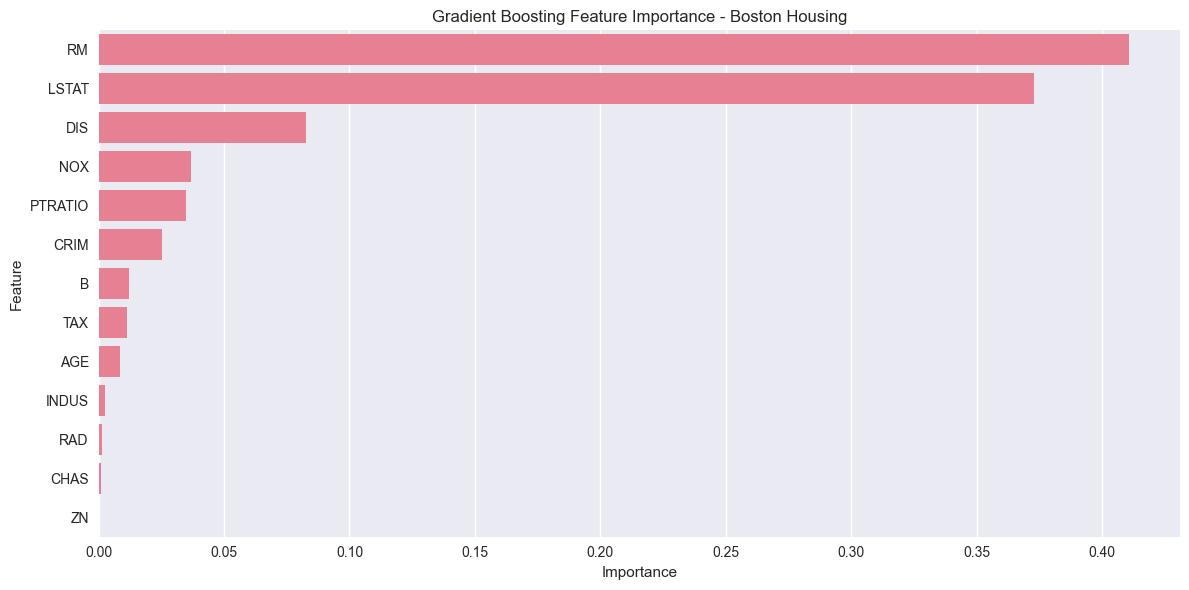

In [90]:
# Feature importance
gb_pipeline.fit(X_boston, y_boston)
feature_importance_gb = gb_pipeline[1].feature_importances_

plt.figure(figsize=(12, 6))
feature_imp_df = pd.DataFrame({'Feature': X_boston.columns, 'Importance': feature_importance_gb})
feature_imp_df = feature_imp_df.sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Gradient Boosting Feature Importance - Boston Housing')
plt.tight_layout()
plt.show()

#### Exercises from example 4

In [91]:
# Practice Exercises for Example 4
print("\nPractice Exercises for Boston Housing:")
print("1. Try different learning rates and max_depth for Gradient Boosting.")
print("2. Implement early stopping using validation_fraction and n_iter_no_change.")



Practice Exercises for Boston Housing:
1. Try different learning rates and max_depth for Gradient Boosting.
2. Implement early stopping using validation_fraction and n_iter_no_change.


## Regression Example 5: Linnerud Dataset with SVR

In [105]:
print("\n\n5. LINNERUD DATASET - SUPPORT VECTOR REGRESSION WITH REPEATED K-FOLD")
print("-" * 80)

# Load Linnerud dataset (fitness measurements)
linnerud = load_linnerud()
X_linn, y_linn = linnerud.data, linnerud.target

# We'll predict just the first target (weight)
y_weight = y_linn[:, 0]

# Create pipeline
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf', C=100, gamma='scale'))
])

# K-Fold cross-validation
kfold_reg = KFold(n_splits=3, shuffle=True, random_state=42)

# Perform cross-validation
svr_scores = cross_validate(svr_pipeline, X_linn, y_weight, cv=kfold_reg,
                           scoring=['neg_mean_squared_error', 'r2'])

print(f"R² Score: {svr_scores['test_r2'].mean():.4f} ± {svr_scores['test_r2'].std():.4f}")
print(f"MSE: {svr_scores['test_neg_mean_squared_error'].mean():.4f} ± {svr_scores['test_neg_mean_squared_error'].std():.4f}")



5. LINNERUD DATASET - SUPPORT VECTOR REGRESSION WITH REPEATED K-FOLD
--------------------------------------------------------------------------------
R² Score: -0.9399 ± 1.2759
MSE: -746.8040 ± 269.7631


In [104]:
import sklearn
sklearn.metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

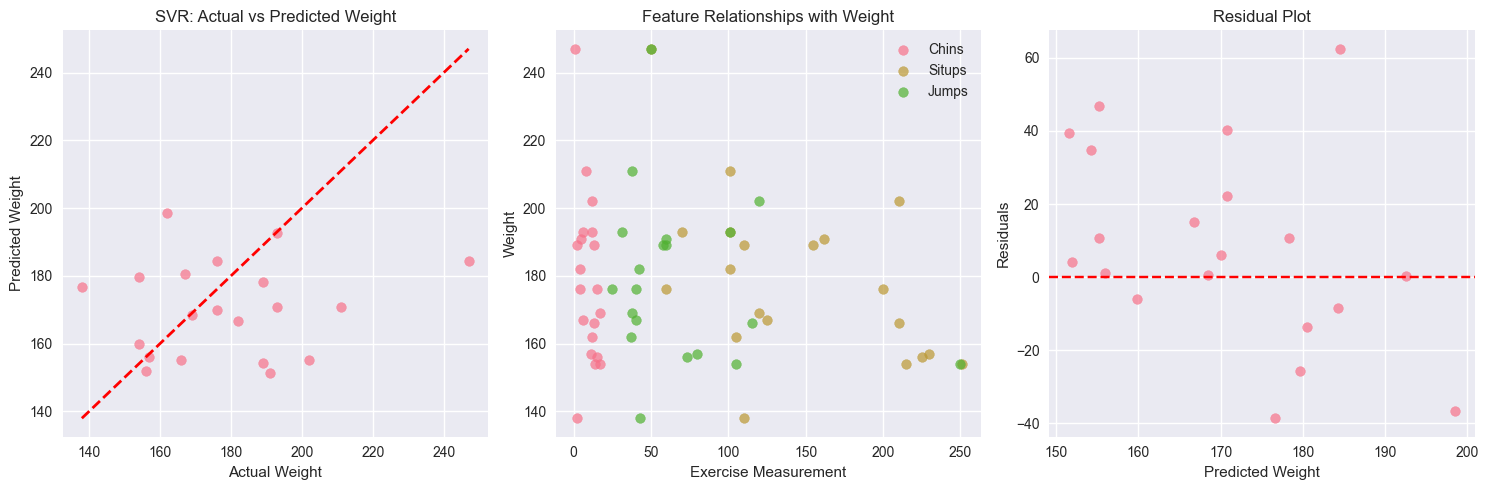

In [106]:
# Get predictions
y_pred_svr = cross_val_predict(svr_pipeline, X_linn, y_weight, cv=kfold_reg)

# Visualize results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_weight, y_pred_svr, alpha=0.7)
plt.plot([y_weight.min(), y_weight.max()], [y_weight.min(), y_weight.max()], 'r--', lw=2)
plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.title('SVR: Actual vs Predicted Weight')

plt.subplot(1, 3, 2)
for i, feature_name in enumerate(linnerud.feature_names):
    plt.scatter(X_linn[:, i], y_weight, alpha=0.7, label=feature_name)
plt.xlabel('Exercise Measurement')
plt.ylabel('Weight')
plt.title('Feature Relationships with Weight')
plt.legend()

plt.subplot(1, 3, 3)
residuals_svr = y_weight - y_pred_svr
plt.scatter(y_pred_svr, residuals_svr, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Weight')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [108]:
param_grid = {
    'regressor__C': [0.1, 1, 10, 100],
    'regressor__gamma': ['scale', 'auto', 0.1, 0.01]
}

grid_search_svr = GridSearchCV(svr_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_svr.fit(X_linn, y_weight)

print(f"\nBest parameters: {grid_search_svr.best_params_}")
print(f"Best R² score: {grid_search_svr.best_score_:.4f}")


Best parameters: {'regressor__C': 100, 'regressor__gamma': 0.1}
Best R² score: -640.2281


#### Exercises from example 5

In [109]:
print("\nPractice Exercises for Linnerud Dataset:")
print("1. Compare different SVR kernels (linear, poly, sigmoid) and their performance.")
print("2. Try to predict all three target variables using a MultiOutputRegressor.")


Practice Exercises for Linnerud Dataset:
1. Compare different SVR kernels (linear, poly, sigmoid) and their performance.
2. Try to predict all three target variables using a MultiOutputRegressor.


## Regression Example 6: Generate_sine_wave with K-Nearest Neighbors

In [115]:
print("\n\n6. SINE WAVE - K-NEAREST NEIGHBORS REGRESSION WITH CV")
print("-" * 65)

# Generate a sine wave dataset
def generate_sine_wave(n_samples=200, noise=0.1):
    X = np.random.uniform(0, 10, n_samples).reshape(-1, 1)
    y = np.sin(X.ravel()) + np.random.normal(0, noise, n_samples)
    return X, y

X_sine, y_sine = generate_sine_wave(n_samples=200, noise=0.1)

# Create pipeline
knn_reg_pipeline = Pipeline([
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])

# KFold cross-validation
kfold_sine = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
knn_scores = cross_validate(knn_reg_pipeline, X_sine, y_sine, cv=kfold_sine,
                           scoring=['neg_mean_squared_error', 'r2'])

print(f"R² Score: {knn_scores['test_r2'].mean():.4f} ± {knn_scores['test_r2'].std():.4f}")
print(f"MSE: {-knn_scores['test_neg_mean_squared_error'].mean():.4f} ± {knn_scores['test_neg_mean_squared_error'].std():.4f}")



6. SINE WAVE - K-NEAREST NEIGHBORS REGRESSION WITH CV
-----------------------------------------------------------------
R² Score: 0.9655 ± 0.0107
MSE: 0.0147 ± 0.0044


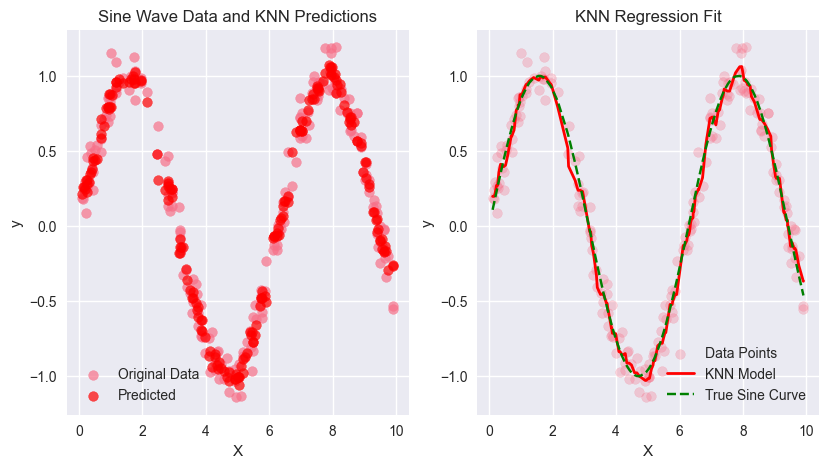

In [116]:
# Get predictions
y_pred_knn = cross_val_predict(knn_reg_pipeline, X_sine, y_sine, cv=kfold_sine)

# Plot sine wave and predictions
plt.figure(figsize=(15, 5))

# Original data vs predictions
plt.subplot(1, 3, 1)
plt.scatter(X_sine, y_sine, alpha=0.7, label='Original Data')
plt.scatter(X_sine, y_pred_knn, alpha=0.7, label='Predicted', color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Sine Wave Data and KNN Predictions')
plt.legend()

# Continuous curve with sorted points
plt.subplot(1, 3, 2)
X_sorted = np.sort(X_sine, axis=0)
knn_reg_pipeline.fit(X_sine, y_sine)
y_smooth = knn_reg_pipeline.predict(X_sorted)
plt.scatter(X_sine, y_sine, alpha=0.3, label='Data Points')
plt.plot(X_sorted, y_smooth, 'r-', linewidth=2, label='KNN Model')
plt.plot(X_sorted, np.sin(X_sorted.ravel()), 'g--', label='True Sine Curve')
plt.xlabel('X')
plt.ylabel('y')
plt.title('KNN Regression Fit')
plt.legend()

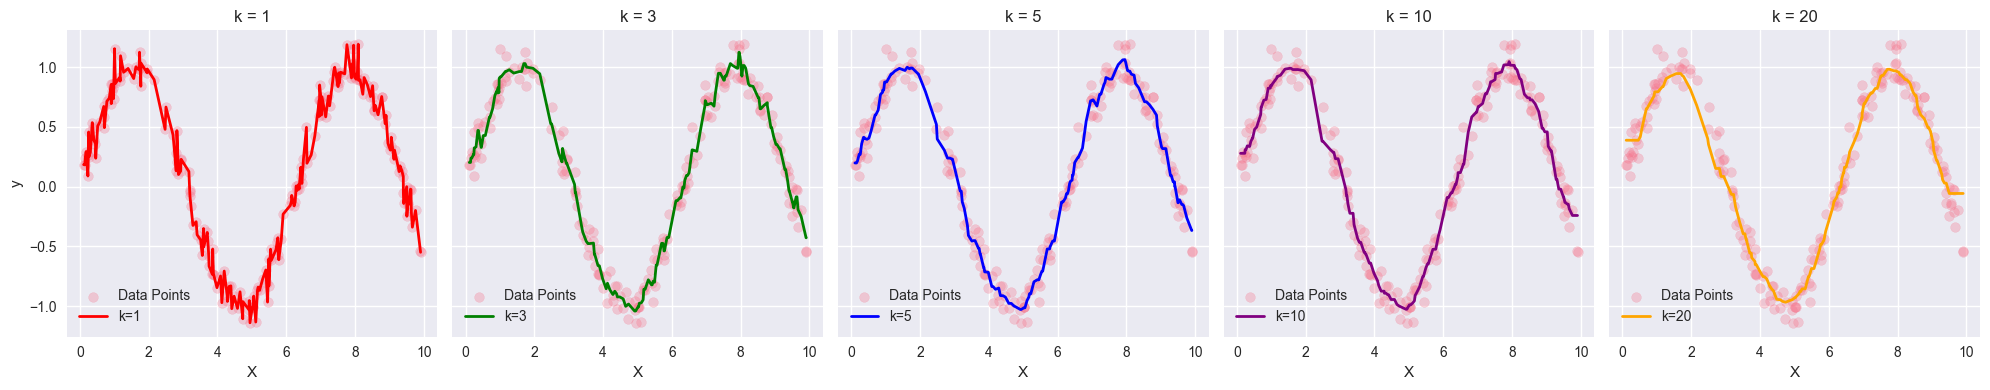

In [117]:
# Define the k values and corresponding colors for the plots
k_values = [1, 3, 5, 10, 20]
colors = ['red', 'green', 'blue', 'purple', 'orange']

# Create a figure and a set of subplots (axes)
# This creates 1 row with 5 columns of subplots, sharing a common y-axis[1].
fig, axes = plt.subplots(1, len(k_values), figsize=(20, 4), sharey=True)

# Iterate through each k value and its corresponding subplot axis
for i, k in enumerate(k_values):
    # Select the current subplot axis
    ax = axes[i]
    
    # Initialize and fit the KNeighborsRegressor model[1]
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_sine, y_sine)
    
    # Predict on the sorted X values to create a smooth line
    y_pred_k = knn.predict(X_sorted)
    
    # Plot the original data points and the model's prediction line on the current axis
    ax.scatter(X_sine, y_sine, alpha=0.3, label='Data Points')
    ax.plot(X_sorted, y_pred_k, color=colors[i], lw=2, label=f'k={k}')
    
    # Set labels and a unique title for each subplot[1]
    ax.set_xlabel('X')
    ax.set_title(f'k = {k}')
    ax.legend()

# Set the y-label only for the first subplot to avoid redundancy
axes[0].set_ylabel('y')

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout()
plt.show()

#### Exercises from example 6

In [118]:
# Practice Exercises for Example 6
print("\nPractice Exercises for Sine Wave:")
print("1. Experiment with different weights ('uniform' vs 'distance') in KNN regressor.")
print("2. Try different noise levels and observe how KNN performance changes.")


Practice Exercises for Sine Wave:
1. Experiment with different weights ('uniform' vs 'distance') in KNN regressor.
2. Try different noise levels and observe how KNN performance changes.


## Regression Example 7: Fetch_california_housing with Lasso Regression

In [119]:
print("\n\n7. CALIFORNIA HOUSING (SUBSET) - LASSO WITH LEAVE-P-OUT CV")
print("-" * 75)

# Load subset of California housing for computational efficiency
calif_subset = fetch_california_housing()
X_calif_sub, y_calif_sub = calif_subset.data[:1000], calif_subset.target[:1000]

# Create pipeline
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Lasso(alpha=0.1, random_state=42))
])

# Leave-P-Out cross-validation
lpo = LeavePOut(p=2)  # Leave 2 samples out
# Use only first 100 samples for LPO due to computational cost
X_small, y_small = X_calif_sub[:100], y_calif_sub[:100]

# Perform cross-validation
lasso_scores = cross_validate(lasso_pipeline, X_small, y_small, cv=lpo,
                             scoring=['neg_mean_squared_error', 'r2'])

print(f"R² Score: {lasso_scores['test_r2'].mean():.4f} ± {lasso_scores['test_r2'].std():.4f}")
print(f"MSE: {-lasso_scores['test_neg_mean_squared_error'].mean():.4f} ± {lasso_scores['test_neg_mean_squared_error'].std():.4f}")



7. CALIFORNIA HOUSING (SUBSET) - LASSO WITH LEAVE-P-OUT CV
---------------------------------------------------------------------------
R² Score: -216.7687 ± 3551.7383
MSE: 0.2870 ± 0.9200


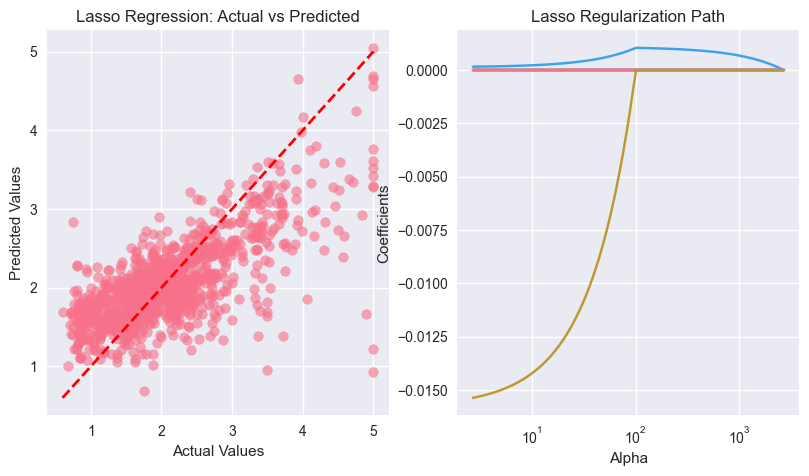

In [120]:
# For visualization, use the larger subset with KFold
y_pred_lasso = cross_val_predict(lasso_pipeline, X_calif_sub, y_calif_sub, cv=5)

# Plot results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_calif_sub, y_pred_lasso, alpha=0.6)
plt.plot([y_calif_sub.min(), y_calif_sub.max()], [y_calif_sub.min(), y_calif_sub.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Lasso Regression: Actual vs Predicted')

# Regularization path
from sklearn.linear_model import lasso_path
alphas_lasso, coefs_lasso, _ = lasso_path(X_calif_sub, y_calif_sub, alphas=None)

plt.subplot(1, 3, 2)
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i, :])
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Regularization Path')
plt.xscale('log')


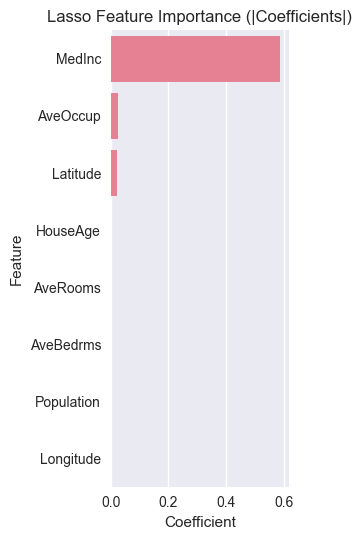


Optimal alpha: 0.134351


In [121]:
# Feature importance (absolute coefficients)
lasso_pipeline.fit(X_calif_sub, y_calif_sub)
lasso_coefs = lasso_pipeline[1].coef_

plt.subplot(1, 3, 3)
feature_names = calif_subset.feature_names
coef_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': np.abs(lasso_coefs)})
coef_importance = coef_importance.sort_values('Coefficient', ascending=False)
sns.barplot(x='Coefficient', y='Feature', data=coef_importance)
plt.title('Lasso Feature Importance (|Coefficients|)')
plt.tight_layout()
plt.show()

# Alpha selection with cross-validation
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_calif_sub, y_calif_sub)
print(f"\nOptimal alpha: {lasso_cv.alpha_:.6f}")

#### Exercises from Example 7

In [122]:
# Practice Exercises for Example 7
print("\nPractice Exercises for Lasso Regression:")
print("1. Compare Lasso with Ridge regression and observe feature selection differences.")
print("2. Use ElasticNet with different l1_ratio values and compare results.")


Practice Exercises for Lasso Regression:
1. Compare Lasso with Ridge regression and observe feature selection differences.
2. Use ElasticNet with different l1_ratio values and compare results.


## Regression Example 8: Synthetic polynomial data with Polynomial Features

In [124]:
print("\n\n8. POLYNOMIAL REGRESSION - PIPELINE WITH CROSS-VALIDATION")
print("-" * 70)

# Generate polynomial data
def generate_polynomial_data(n_samples=100, degree=3, noise=0.1):
    X = np.random.uniform(-2, 2, n_samples).reshape(-1, 1)
    y = X[:, 0]**degree + 0.5*X[:, 0]**2 + np.random.normal(0, noise, n_samples)
    return X, y

X_poly, y_poly = generate_polynomial_data(n_samples=150, degree=3, noise=0.2)

# Create polynomial pipeline
from sklearn.preprocessing import PolynomialFeatures

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Cross-validation
poly_scores = cross_validate(poly_pipeline, X_poly, y_poly, cv=5,
                           scoring=['neg_mean_squared_error', 'r2'])

print(f"R² Score: {poly_scores['test_r2'].mean():.4f} ± {poly_scores['test_r2'].std():.4f}")
print(f"MSE: {poly_scores['test_neg_mean_squared_error'].mean():.4f} ± {poly_scores['test_neg_mean_squared_error'].std():.4f}")



8. POLYNOMIAL REGRESSION - PIPELINE WITH CROSS-VALIDATION
----------------------------------------------------------------------
R² Score: 0.9954 ± 0.0018
MSE: -0.0419 ± 0.0048


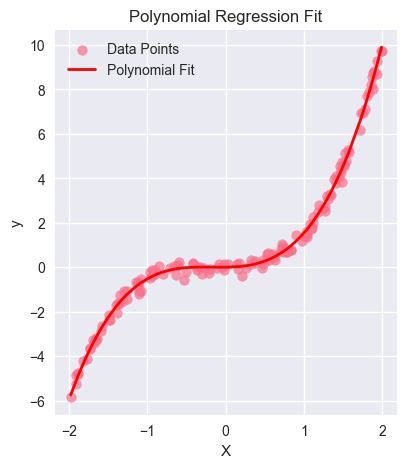

In [125]:
# Get predictions
y_pred_poly = cross_val_predict(poly_pipeline, X_poly, y_poly, cv=5)

# Plot results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_poly, y_poly, alpha=0.7, label='Data Points')
X_sorted = np.sort(X_poly, axis=0)
poly_pipeline.fit(X_poly, y_poly)
y_smooth = poly_pipeline.predict(X_sorted)
plt.plot(X_sorted, y_smooth, 'r-', linewidth=2, label='Polynomial Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Fit')
plt.legend()

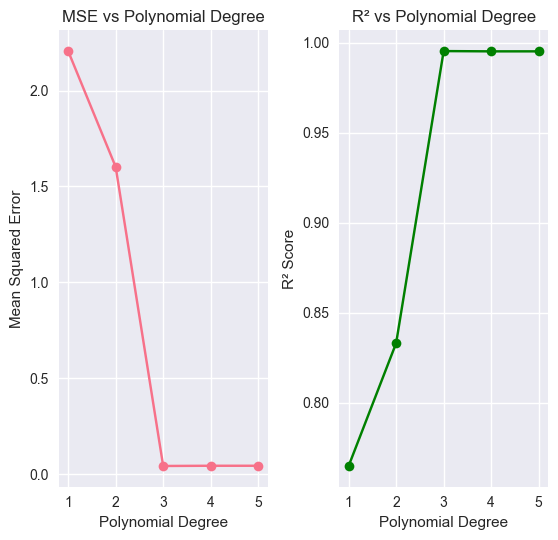

In [126]:
# Compare different polynomial degrees
plt.subplot(1, 3, 2)
degrees = [1, 2, 3, 4, 5]
mse_scores = []
r2_scores = []

for degree in degrees:
    poly_temp = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])
    scores = cross_validate(poly_temp, X_poly, y_poly, cv=5, 
                          scoring=['neg_mean_squared_error', 'r2'])
    mse_scores.append(-scores['test_neg_mean_squared_error'].mean())
    r2_scores.append(scores['test_r2'].mean())

plt.plot(degrees, mse_scores, 'o-', label='MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs Polynomial Degree')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(degrees, r2_scores, 'o-', color='green', label='R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('R² vs Polynomial Degree')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Exercises from Example 8

In [127]:
# Practice Exercises for Example 8
print("\nPractice Exercises for Polynomial Regression:")
print("1. Investigate overfitting by plotting training vs validation curves for different degrees.")
print("2. Apply regularization (Ridge/Lasso) to high-degree polynomial features.")


Practice Exercises for Polynomial Regression:
1. Investigate overfitting by plotting training vs validation curves for different degrees.
2. Apply regularization (Ridge/Lasso) to high-degree polynomial features.


## Regression Example 9: Energy Efficiency with Multi-layer Perceptron

In [148]:
print("\n\n9. ENERGY EFFICIENCY - MLP REGRESSOR WITH VALIDATION CURVE")
print("-" * 75)

# Load energy efficiency dataset
energy = fetch_openml(name='energy-efficiency', version=1, return_X_y=True, as_frame=True)
X_energy, y_energy = energy

# Handle different target formats
if hasattr(y_energy, 'iloc') and len(y_energy.shape) > 1:
    # If it's a DataFrame with multiple columns
    y_heating = np.array(y_energy.iloc[:, 0]).astype(float)
elif hasattr(y_energy, 'iloc'):
    # If it's a pandas Series
    y_heating = np.array(y_energy).astype(float)
else:
    # If it's a numpy array or other format
    y_heating = np.array(y_energy).astype(float)

# Create MLP pipeline
from sklearn.neural_network import MLPRegressor

mlp_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
])

# Cross-validation
mlp_reg_scores = cross_validate(mlp_reg_pipeline, X_energy, y_heating, cv=5,
                               scoring=['neg_mean_squared_error', 'r2'])

print(f"R² Score: {mlp_reg_scores['test_r2'].mean():.4f} ± {mlp_reg_scores['test_r2'].std():.4f}")
print(f"MSE: {-mlp_reg_scores['test_neg_mean_squared_error'].mean():.4f} ± {mlp_reg_scores['test_neg_mean_squared_error'].std():.4f}")




9. ENERGY EFFICIENCY - MLP REGRESSOR WITH VALIDATION CURVE
---------------------------------------------------------------------------
R² Score: 0.7300 ± 0.4708
MSE: 30.9587 ± 55.5224


In [151]:
y_heating.max()

np.float64(37.0)

Text(0.5, 1.0, 'Residual Plot')

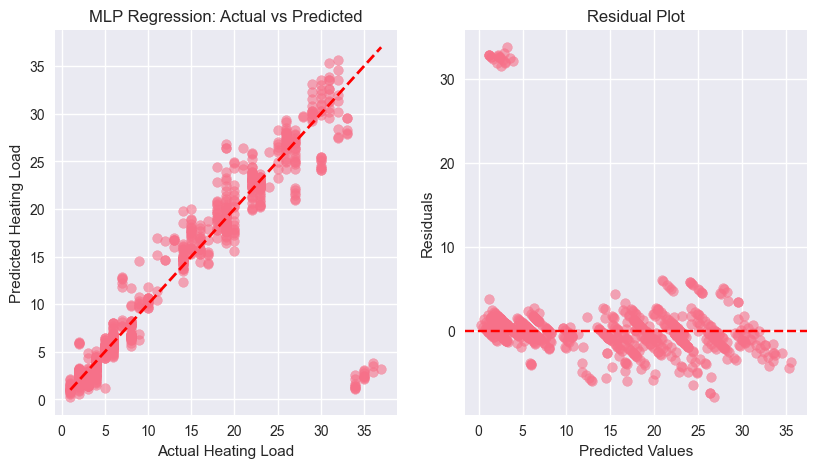

In [153]:
# Get predictions
y_pred_mlp = cross_val_predict(mlp_reg_pipeline, X_energy, y_heating, cv=5)

# Visualize results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_heating, y_pred_mlp, alpha=0.6)
plt.plot([y_heating.min(), y_heating.max()], [y_heating.min(), y_heating.max()], 'r--', lw=2)
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title('MLP Regression: Actual vs Predicted')

# Residuals
residuals_mlp = y_heating - y_pred_mlp
plt.subplot(1, 3, 2)
plt.scatter(y_pred_mlp, residuals_mlp, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

/Users/gabriel/miniforge3/envs/mlup/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/gabriel/miniforge3/envs/mlup/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/gabriel/miniforge3/envs/mlup/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/gabriel/miniforge3/envs/mlup/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
 

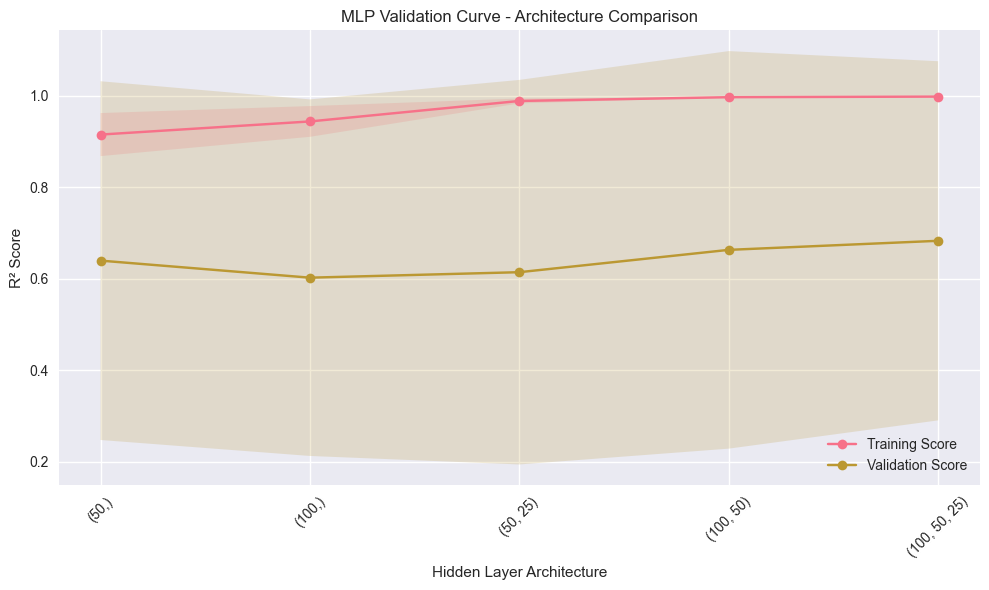

In [154]:
# Validation curve for hidden layer size
hidden_layer_sizes = [(50,), (100,), (50, 25), (100, 50), (100, 50, 25)]
param_range = [str(h) for h in hidden_layer_sizes]  # For plotting

train_scores_mlp, val_scores_mlp = validation_curve(
    MLPRegressor(max_iter=1000, random_state=42), 
    StandardScaler().fit_transform(X_energy), y_heating,
    param_name='hidden_layer_sizes', param_range=hidden_layer_sizes,
    cv=3, scoring='r2', n_jobs=-1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_scores_mlp.mean(axis=1), 'o-', label='Training Score')
plt.fill_between(param_range, train_scores_mlp.mean(axis=1) - train_scores_mlp.std(axis=1),
                 train_scores_mlp.mean(axis=1) + train_scores_mlp.std(axis=1), alpha=0.2)
plt.plot(param_range, val_scores_mlp.mean(axis=1), 'o-', label='Validation Score')
plt.fill_between(param_range, val_scores_mlp.mean(axis=1) - val_scores_mlp.std(axis=1),
                 val_scores_mlp.mean(axis=1) + val_scores_mlp.std(axis=1), alpha=0.2)
plt.xlabel('Hidden Layer Architecture')
plt.ylabel('R² Score')
plt.title('MLP Validation Curve - Architecture Comparison')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Exercises from Example 9

In [155]:
# Practice Exercises for Example 9
print("\nPractice Exercises for Energy Efficiency:")
print("1. Try different activation functions (relu, tanh, logistic) and compare performance.")
print("2. Experiment with different learning rates and early stopping criteria.")


Practice Exercises for Energy Efficiency:
1. Try different activation functions (relu, tanh, logistic) and compare performance.
2. Experiment with different learning rates and early stopping criteria.


## Regression Example 10: Combined dataset with Ensemble Methods

In [156]:
print("\n\n10. ENSEMBLE REGRESSION - VOTING REGRESSOR WITH NESTED CV")
print("-" * 75)

# Use California housing dataset for ensemble
X_ensemble, y_ensemble = fetch_california_housing(return_X_y=True)

# Create individual regressors
from sklearn.ensemble import VotingRegressor

reg1 = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])
reg2 = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge(alpha=1.0))])
reg3 = Pipeline([('scaler', StandardScaler()), ('regressor', RandomForestRegressor(n_estimators=50, random_state=42))])

# Voting regressor
voting_reg = VotingRegressor(estimators=[('lr', reg1), ('ridge', reg2), ('rf', reg3)])

# Nested cross-validation
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Nested cross-validation scores
nested_scores = cross_validate(voting_reg, X_ensemble, y_ensemble, cv=outer_cv,
                              scoring=['neg_mean_squared_error', 'r2'])

print(f"Nested CV R² Score: {nested_scores['test_r2'].mean():.4f} ± {nested_scores['test_r2'].std():.4f}")
print(f"Nested CV MSE: {-nested_scores['test_neg_mean_squared_error'].mean():.4f} ± {nested_scores['test_neg_mean_squared_error'].std():.4f}")



10. ENSEMBLE REGRESSION - VOTING REGRESSOR WITH NESTED CV
---------------------------------------------------------------------------
Nested CV R² Score: 0.7158 ± 0.0140
Nested CV MSE: 0.3783 ± 0.0187


([0, 1, 2, 3],
 [Text(0, 0, 'Linear Regression'),
  Text(1, 0, 'Ridge'),
  Text(2, 0, 'Random Forest'),
  Text(3, 0, 'Ensemble')])

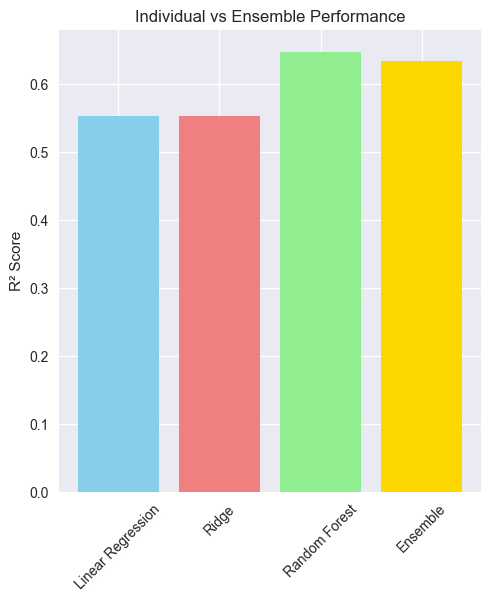

In [157]:
# Compare individual vs ensemble performance
individual_scores = {}
for name, reg in [('Linear Regression', reg1), ('Ridge', reg2), ('Random Forest', reg3)]:
    scores = cross_val_score(reg, X_ensemble, y_ensemble, cv=5, scoring='r2')
    individual_scores[name] = scores.mean()

ensemble_score = cross_val_score(voting_reg, X_ensemble, y_ensemble, cv=5, scoring='r2').mean()

# Visualize performance comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
names = list(individual_scores.keys()) + ['Ensemble']
scores = list(individual_scores.values()) + [ensemble_score]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
bars = plt.bar(names, scores, color=colors)
plt.title('Individual vs Ensemble Performance')
plt.ylabel('R² Score')
plt.xticks(rotation=45)

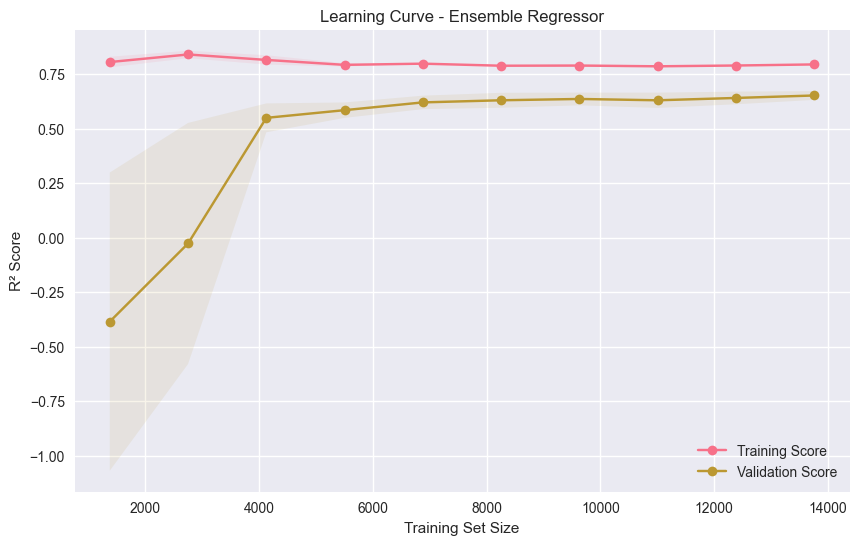

In [160]:
# Learning curves for ensemble
train_sizes_ens, train_scores_ens, val_scores_ens = learning_curve(
    voting_reg, X_ensemble, y_ensemble, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2')

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_ens, train_scores_ens.mean(axis=1), 'o-', label='Training Score')
plt.fill_between(train_sizes_ens, train_scores_ens.mean(axis=1) - train_scores_ens.std(axis=1),
                 train_scores_ens.mean(axis=1) + train_scores_ens.std(axis=1), alpha=0.1)
plt.plot(train_sizes_ens, val_scores_ens.mean(axis=1), 'o-', label='Validation Score')
plt.fill_between(train_sizes_ens, val_scores_ens.mean(axis=1) - val_scores_ens.std(axis=1),
                 val_scores_ens.mean(axis=1) + val_scores_ens.std(axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve - Ensemble Regressor')
plt.legend()
plt.grid(True)
plt.show()


#### Exercises from Example 10

In [159]:
# Practice Exercises for Example 10
print("\nPractice Exercises for Ensemble Regression:")
print("1. Try stacking regressor instead of voting and compare performance.")
print("2. Add more diverse regressors (SVR, KNN, Gradient Boosting) to the ensemble.")


Practice Exercises for Ensemble Regression:
1. Try stacking regressor instead of voting and compare performance.
2. Add more diverse regressors (SVR, KNN, Gradient Boosting) to the ensemble.
